# LXMERT: Learning Cross-Modality Encoder Representations from Transformers

# https://arxiv.org/pdf/1908.07490

**Authors:** Hao Tan, Mohit Bansal — UNC Chapel Hill
**Venue:** EMNLP 2019

---

## Abstract

LXMERT is a large-scale Transformer-based framework designed to learn the connections between
vision and language. It consists of three encoders — an object-relationship encoder, a language
encoder, and a cross-modality encoder — pre-trained on 9.18M image-sentence pairs via five
diverse tasks. The model achieves state-of-the-art results on VQA, GQA, and NLVR2.

---

## Problems

- Vision-and-language reasoning requires understanding of visual concepts, language semantics,
  and — most critically — the alignment between these two modalities.
- Prior work focused on single-modality pre-training (e.g., BERT for language, ResNet/Faster
  R-CNN for vision), leaving cross-modal pre-training largely underdeveloped.
- Directly adapting language-only models like BERT to vision-language tasks is insufficient;
  BERT tends to rely on language cues alone without learning genuine cross-modal connections.

---

## Proposed Solutions

- A new model architecture with **three Transformer encoders**: an object-relationship encoder
  (vision), a language encoder, and a cross-modality encoder that exchanges information
  bidirectionally between the two modalities.
- A **multi-task pre-training strategy** with five tasks spanning language, vision, and
  cross-modality objectives.
- Large-scale pre-training on an aggregated dataset of **9.18M image-sentence pairs** from
  MS COCO and Visual Genome.

---

## Purpose

To build a universal pre-trained cross-modality backbone that:

1. Learns rich intra-modality representations for both vision and language.
2. Learns cross-modal alignments between visual objects and language tokens.
3. Generalizes to diverse downstream vision-and-language tasks through fine-tuning.

---

## Methodology

### 2.1 Input Embeddings

**Word-level sentence embeddings** combine word and positional index embeddings:

$$h_i = \text{LayerNorm}(\hat{w}_i + \hat{u}_i)$$

**Object-level image embeddings** combine RoI features $f_j$ and position features $p_j$:

$$v_j = \left(\hat{f}_j + \hat{p}_j\right) / 2$$

### 2.2 Encoders

**Single-modality encoders** (language encoder: $N_L = 9$ layers; object-relationship encoder:
$N_R = 5$ layers) apply standard Transformer self-attention within each modality independently.

**Cross-modality encoder** ($N_X = 5$ layers) applies bidirectional cross-attention between
modalities at each layer:

$$\hat{h}_i^k = \text{CrossAtt}_{L \to R}\left(h_i^{k-1},\ \{v_1^{k-1}, \ldots, v_m^{k-1}\}\right)$$

$$\hat{v}_j^k = \text{CrossAtt}_{R \to L}\left(v_j^{k-1},\ \{h_1^{k-1}, \ldots, h_n^{k-1}\}\right)$$

Followed by intra-modality self-attention and feed-forward layers at each cross-modality layer.

### 2.3 Output Representations

Three output streams are produced:
- **Language output**: sequence of language features from the cross-modality encoder.
- **Vision output**: sequence of vision features from the cross-modality encoder.
- **Cross-modality output**: the feature vector of the special `[CLS]` token, used as a
  holistic image-sentence representation.

### 3.1 Pre-Training Tasks

| Task | Modality | Objective |
|---|---|---|
| Masked Cross-Modality LM | Language | Predict masked words using language + vision context |
| RoI-Feature Regression | Vision | Regress masked object RoI features using $L_2$ loss |
| Detected-Label Classification | Vision | Classify masked objects using cross-entropy loss |
| Cross-Modality Matching | Cross | Predict whether an image-sentence pair is matched |
| Image Question Answering | Cross | Predict answers to image-related questions |

### 3.2 Pre-Training Data

| Source | Images | Sentences/Questions |
|---|---|---|
| MS COCO + VG (non-overlapping) | 180K total | 9.18M pairs |

Datasets used: COCO Captions, VG Captions, VQA v2.0, GQA, VG-QA.

### 3.3 Pre-Training Procedure

- Optimizer: Adam with linear-decayed learning rate schedule; peak lr $= 1 \times 10^{-4}$
- Training: 20 epochs (batch size 256); image QA loss applied only in last 10 epochs
- Hardware: 4 Titan Xp GPUs; total pre-training time ~10 days
- Objects per image: fixed at 36 (extracted by frozen Faster R-CNN)

---

## Results

### Main Results (Test Set)

| Method | VQA Accu | GQA Accu | NLVR2 Accu | NLVR2 Cons |
|---|---|---|---|---|
| Prior State-of-the-Art | 70.4% | 57.1% | 53.5% | 12.0% |
| **LXMERT** | **72.5%** | **60.3%** | **76.2%** | **42.1%** |

Key improvements:
- **+2.1%** overall accuracy on VQA over prior SotA
- **+3.2%** accuracy on GQA
- **+22.7%** absolute accuracy on NLVR2 (54% → 76%), representing ~48% relative error reduction
- **+30.1%** absolute consistency on NLVR2 (12% → 42%)

### Ablation Findings

- Replacing LXMERT pre-training with BERT initialization degrades performance by ~22% on NLVR2,
  confirming that cross-modal pre-training is essential.
- Adding more cross-attention layers without cross-modal pre-training saturates at 3 layers with
  a 3.4% gap to the full LXMERT model.
- Both RoI-feature regression and detected-label classification contribute positively; their
  combination yields the highest results.
- Image QA pre-training improves all three downstream tasks, outperforming data augmentation
  as an alternative strategy.

---

## Conclusions

LXMERT demonstrates that a dedicated cross-modality pre-training framework — combining a
carefully designed three-encoder architecture with diverse multi-task pre-training objectives —
significantly outperforms approaches that adapt single-modality pre-trained models (e.g., BERT)
to vision-language tasks. The 22% absolute improvement on NLVR2, a dataset entirely unseen
during pre-training, establishes the strong generalizability of the learned cross-modal
representations. The work highlights that cross-modality connections cannot be incidentally
learned from language-only pre-training and that explicit vision-language alignment tasks are
critical for robust multimodal understanding.

# LXMERT: Mathematical and Statistical Content Summary

---

## 1. Input Embedding Equations

### 1.1 Word-Level Sentence Embeddings

Each word $w_i$ at position $i$ is embedded as:

$$\hat{w}_i = \text{WordEmbed}(w_i)$$

$$\hat{u}_i = \text{IdxEmbed}(i)$$

$$h_i = \text{LayerNorm}(\hat{w}_i + \hat{u}_i)$$

**Explanation:** Each word is converted into a dense vector, and its position index is
separately embedded. The two vectors are summed and normalized. Layer normalization
stabilizes the scale of activations across the feature dimension, preventing
any single source of information from dominating.

---

### 1.2 Object-Level Image Embeddings

Each detected object $o_j$ has an RoI feature $f_j \in \mathbb{R}^{2048}$ and a
bounding-box position feature $p_j$. These are projected and combined as:

$$\hat{f}_j = \text{LayerNorm}(W_F f_j + b_F)$$

$$\hat{p}_j = \text{LayerNorm}(W_P p_j + b_P)$$

$$v_j = \left(\hat{f}_j + \hat{p}_j\right) / 2$$

**Explanation:** The visual appearance feature and the spatial position feature are
each linearly projected and independently normalized before averaging. The
independent layer normalization before summation is critical — it balances
the energy (scale) of the two heterogeneous feature types, preventing one
from overwhelming the other in subsequent attention computations.

---

## 2. Attention Mechanism

### 2.1 General Attention Layer

Given a query vector $x$ and a set of context vectors $\{y_j\}$, the attention
score and normalized weight are computed as:

$$a_j = \text{score}(x,\ y_j)$$

$$\alpha_j = \frac{\exp(a_j)}{\sum_k \exp(a_k)}$$

The output is the weighted sum of context vectors:

$$\text{Att}_{X \to Y}(x,\ \{y_j\}) = \sum_j \alpha_j y_j$$

**Explanation:** The attention mechanism allows the model to selectively focus on
the most relevant context vectors given a query. The softmax normalization
ensures all weights sum to 1, forming a proper probability distribution over
the context set. In LXMERT, this is applied as multi-head attention following
the standard Transformer formulation.

---

### 2.2 Self-Attention

Self-attention is a special case where the query $x$ is itself a member of the
context set $\{y_j\}$:

$$\text{SelfAtt}(x,\ \{y_j\}) = \sum_j \alpha_j y_j, \quad x \in \{y_j\}$$

**Explanation:** Self-attention allows each element in a sequence to attend to all
other elements in the same sequence. In LXMERT, this is used within the
language encoder (word-to-word attention) and the object-relationship encoder
(object-to-object attention) to build intra-modality contextual representations.

---

## 3. Cross-Modality Encoder Equations

At each layer $k$, bidirectional cross-attention is computed between language
features $\{h_i^{k-1}\}$ and vision features $\{v_j^{k-1}\}$:

### 3.1 Bidirectional Cross-Attention

Language attends to vision:

$$\hat{h}_i^k = \text{CrossAtt}_{L \to R}\!\left(h_i^{k-1},\ \{v_1^{k-1}, \ldots, v_m^{k-1}\}\right)$$

Vision attends to language:

$$\hat{v}_j^k = \text{CrossAtt}_{R \to L}\!\left(v_j^{k-1},\ \{h_1^{k-1}, \ldots, h_n^{k-1}\}\right)$$

**Explanation:** At every layer of the cross-modality encoder, each language token
gathers information from all visual objects, and each visual object gathers
information from all language tokens. This bidirectional flow is the core
mechanism by which LXMERT aligns visual and linguistic entities.

---

### 3.2 Intra-Modality Self-Attention (Post Cross-Attention)

After cross-attention, self-attention is applied within each modality:

$$\tilde{h}_i^k = \text{SelfAtt}_{L \to L}\!\left(\hat{h}_i^k,\ \{\hat{h}_1^k, \ldots, \hat{h}_n^k\}\right)$$

$$\tilde{v}_j^k = \text{SelfAtt}_{R \to R}\!\left(\hat{v}_j^k,\ \{\hat{v}_1^k, \ldots, \hat{v}_m^k\}\right)$$

**Explanation:** After cross-modal information exchange, each modality re-integrates
its own updated features internally. This two-step process — cross-attention
followed by self-attention — ensures both inter-modal alignment and
intra-modal coherence are maintained at each encoder layer.

---

## 4. Pre-Training Loss Functions

### 4.1 Masked Cross-Modality Language Modeling

Words are randomly masked with probability $p = 0.15$. The model predicts
masked tokens using both visible language context and visual features.
The objective is standard cross-entropy loss:

$$\mathcal{L}_{\text{MLM}} = -\sum_{i \in \mathcal{M}} \log P(w_i \mid w_{\backslash \mathcal{M}},\ \{v_j\})$$

where $\mathcal{M}$ is the set of masked word indices.

**Explanation:** Unlike BERT's masked LM which relies solely on surrounding words,
LXMERT can resolve ambiguous masked tokens by also attending to visual
features, directly training cross-modal grounding.

---

### 4.2 Masked Object Prediction — RoI-Feature Regression

Objects are randomly masked with probability $p = 0.15$. The model regresses
the masked object's RoI feature using $L_2$ (mean squared error) loss:

$$\mathcal{L}_{\text{Feat}} = \sum_{j \in \mathcal{M}_v} \left\| f_j - \hat{f}_j^{\text{pred}} \right\|_2^2$$

where $\mathcal{M}_v$ is the set of masked object indices.

**Explanation:** The $L_2$ loss penalizes Euclidean distance between the predicted
and true 2048-dimensional RoI feature vectors, encouraging the model to
reconstruct precise visual appearance from context.

---

### 4.3 Masked Object Prediction — Detected-Label Classification

The model also predicts the discrete class label of each masked object using
cross-entropy loss:

$$\mathcal{L}_{\text{Label}} = -\sum_{j \in \mathcal{M}_v} \log P(c_j \mid \{v_{k \neq j}\},\ \{h_i\})$$

where $c_j$ is the Faster R-CNN detected label for object $j$.

**Explanation:** Complementary to feature regression, label classification trains
the model to predict the semantic category of a masked object, encouraging
higher-level visual semantic understanding alongside low-level feature reconstruction.

---

### 4.4 Combined Pre-Training Objective

All five pre-training losses are combined with equal weights:

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{MLM}} + \mathcal{L}_{\text{Feat}} + \mathcal{L}_{\text{Label}} + \mathcal{L}_{\text{Match}} + \mathcal{L}_{\text{QA}}$$

**Explanation:** Equal weighting treats all pre-training signals as equally important.
This multi-task formulation jointly optimizes language, vision, and cross-modal
objectives, producing representations that are simultaneously grounded in both
modalities.

---

## 5. NLVR2 Fine-Tuning Classifier

For the NLVR2 task, two image-statement pairs are encoded independently and
their cross-modality outputs are concatenated to form a binary classifier:

$$x_0 = \text{LXMERT}(\text{img}_0,\ s), \quad x_1 = \text{LXMERT}(\text{img}_1,\ s)$$

$$z^0 = W_0 [x_0;\ x_1] + b_0$$

$$z^1 = \text{LayerNorm}\!\left(\text{GeLU}(z^0)\right)$$

$$\text{prob} = \sigma(W_1 z^1 + b_1)$$

The binary cross-entropy loss is minimized:

$$\mathcal{L}_{\text{NLVR2}} = -y^* \log(\text{prob}) - (1 - y^*) \log(1 - \text{prob})$$

where $y^* \in \{0, 1\}$ is the ground truth label and $\sigma$ is the sigmoid function.

**Explanation:** The GeLU (Gaussian Error Linear Unit) activation is a smooth,
probabilistic alternative to ReLU, commonly used in Transformer-based models.
The sigmoid output maps the classifier score to a probability in $(0, 1)$,
and the binary cross-entropy loss directly maximizes the log-likelihood of
the correct label.

---

## 6. Optimization and Training Statistics

| Hyperparameter | Value |
|---|---|
| Optimizer | Adam |
| Peak learning rate (pre-training) | $1 \times 10^{-4}$ |
| Learning rate schedule | Linear decay |
| Batch size (pre-training) | $256$ |
| Pre-training epochs | $20$ |
| Fine-tuning learning rate | $1 \times 10^{-5}$ or $5 \times 10^{-5}$ |
| Fine-tuning epochs | $4$ |
| Fine-tuning batch size | $32$ |
| Total optimization steps | $\approx 670{,}000$ |
| Objects per image (fixed) | $36$ |
| Hidden size | $768$ (same as $\text{BERT}_{\text{BASE}}$) |
| Answer candidates (image QA) | $9{,}500$ |

**Explanation:** The Adam optimizer adapts per-parameter learning rates using
first and second moment estimates of the gradient, making it well-suited
for large Transformer models. The linear learning rate decay gradually
reduces the step size as training progresses, preventing overshooting
near convergence.

---

## 7. Architectural Scale Equivalence

The total effective depth of LXMERT is designed to match $\text{BERT}_{\text{BASE}}$
(12 layers). Counting each single-modality layer as one half cross-modality layer:

$$\text{Effective layers} = \frac{N_L + N_R}{2} + N_X = \frac{9 + 5}{2} + 5 = 12$$

**Explanation:** This design choice ensures a fair architectural comparison with
BERT, confirming that LXMERT's performance gains arise from its cross-modal
pre-training strategy rather than from a larger model capacity.

# LXMERT: Problem–Limitation–Solution Analysis

| # | Key Problem / Research Gap | How It Limits Prior Work | Proposed Solution in LXMERT |
|---|---|---|---|
| 1 | **Absence of cross-modality pre-training** — No large-scale framework existed for jointly pre-training vision and language representations. | Models trained on single-modality objectives (e.g., BERT for language, Faster R-CNN for vision) lack shared semantic alignment, forcing downstream tasks to learn cross-modal connections from scratch with limited data. | A dedicated three-encoder architecture — object-relationship encoder, language encoder, and cross-modality encoder — pre-trained end-to-end on 9.18M image-sentence pairs to explicitly learn joint vision-language representations. |
| 2 | **Inadequate visual representation in language-centric models** — Prior models such as BERT operate solely on token sequences and cannot process structured visual inputs. | Applying BERT directly to vision-language tasks causes the model to rely predominantly on language cues, ignoring visual context and failing to learn genuine cross-modal alignments. | Object-level image embeddings that combine 2048-dimensional RoI features $f_j$ with positional bounding-box features $p_j$: $$v_j = \left(\hat{f}_j + \hat{p}_j\right)/2$$ fed into dedicated vision and cross-modality encoders. |
| 3 | **Lack of intra-visual relational reasoning** — Prior vision-language models (e.g., BUTD) treat detected objects as independent feature vectors without modeling inter-object relationships. | Without relational context between objects, models struggle with spatially and semantically complex visual reasoning tasks that require understanding scene structure. | An explicit object-relationship encoder ($N_R = 5$ Transformer layers) applies self-attention over the set of detected objects, enabling the model to learn scene-level relational structure before cross-modal fusion. |
| 4 | **Unidirectional or shallow cross-modal interaction** — Methods such as BUTD and early ViLBERT variants use limited or one-directional attention between visual and linguistic streams. | Shallow cross-modal attention fails to propagate rich contextual signals iteratively between modalities, limiting the depth and quality of learned cross-modal alignment. | A bidirectional cross-attention mechanism applied at every layer of the cross-modality encoder: $$\hat{h}_i^k = \text{CrossAtt}_{L \to R}(h_i^{k-1}, \{v_j^{k-1}\})$$ $$\hat{v}_j^k = \text{CrossAtt}_{R \to L}(v_j^{k-1}, \{h_i^{k-1}\})$$ enabling deep, iterative information exchange across $N_X = 5$ stacked layers. |
| 5 | **Insufficient diversity in pre-training objectives** — Existing cross-modal pre-training methods (e.g., VideoBERT) rely primarily on masked language modeling applied to concatenated token streams. | A single pre-training objective cannot simultaneously capture intra-modal structure and inter-modal alignment, resulting in representations that are suboptimal for tasks requiring complex visual reasoning. | Five complementary pre-training tasks: (1) Masked Cross-Modality LM, (2) RoI-Feature Regression, (3) Detected-Label Classification, (4) Cross-Modality Matching, and (5) Image Question Answering — spanning language, vision, and cross-modality objectives to ensure comprehensive representation learning. |
| 6 | **Limited pre-training data scale and diversity** — Prior vision-language models were pre-trained on small or single-source datasets, restricting generalization. | Models trained on narrow data distributions overfit to specific visual or linguistic domains and fail to generalize to out-of-distribution tasks or unseen image-text pairs. | Aggregation of five large-scale datasets (MS COCO Captions, Visual Genome Captions, VQA v2.0, GQA, VG-QA) yielding **9.18M image-sentence pairs** across **180K distinct images**, covering both captioning and question-answering distributions. |
| 7 | **Poor generalization to unseen visual reasoning tasks** — Fine-tuning single-modality or shallowly fused models on challenging tasks such as NLVR2 yields near-random performance. | Without strong cross-modal pre-training, models cannot bridge the gap between pre-training and structurally distinct downstream tasks, particularly those requiring multi-image or compositional reasoning. | Pre-trained cross-modality representations are adapted to NLVR2 by encoding two image-statement pairs independently and classifying over their concatenated cross-modality outputs, achieving **76.2% accuracy** (+22% absolute over prior SotA) on a dataset entirely excluded from pre-training. |

In [1]:
# ============================================================
# LXMERT-Inspired Cross-Modality Transformer
# Educational Implementation using CIFAR-10 Subset
# Framework: PyTorch | Dataset: CIFAR-10 (subset)
# ============================================================
# NOTE: In the original paper, LXMERT operates on image-sentence
# pairs. Since CIFAR-10 has no captions, we simulate the
# language modality by generating simple synthetic text labels
# (e.g., "a photo of a dog") for each image, mimicking the
# vision-language paired input structure of the paper.
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import math
from collections import defaultdict

In [2]:
# ============================================================
# 0. REPRODUCIBILITY & DEVICE SETUP
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS  = 5
BATCH_SIZE  = 32
LR          = 1e-4
SUBSET_SIZE = 2000   # small subset for fast educational demo
NUM_CLASSES = 10
VOCAB_SIZE  = 50     # tiny synthetic vocabulary
MAX_SEQ_LEN = 8      # tokens per synthetic caption
D_MODEL     = 128    # hidden dimension (lightweight)
N_HEADS     = 4      # attention heads
N_LANG      = 2      # language encoder layers  (NL in paper)
N_VISION    = 2      # object-relationship encoder layers (NR)
N_CROSS     = 2      # cross-modality encoder layers (NX)
NUM_PATCHES = 16     # image split into 4x4 = 16 patches (≈ objects)

print(f"Device: {DEVICE}")
print(f"Subset size : {SUBSET_SIZE} | Epochs: {NUM_EPOCHS} | Batch: {BATCH_SIZE}")

Device: cuda
Subset size : 2000 | Epochs: 5 | Batch: 32


In [3]:
# ============================================================
# 1. CIFAR-10 CLASS NAMES & SYNTHETIC CAPTION GENERATOR
# ============================================================
# We mimic the paper's image-sentence pairs by mapping each
# CIFAR-10 class index to a short synthetic caption string,
# then tokenizing it into integer token IDs.
# ============================================================

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Simple template captions per class
CAPTION_TEMPLATES = [
    "a photo of a {}",
    "an image showing a {}",
    "this is a {}",
    "a picture of a {}",
]

# Build a tiny character-level vocabulary from all captions
def build_vocab():
    """Build a simple word-to-index vocabulary from caption templates."""
    all_words = set(["<PAD>", "<UNK>"])
    for cls in CIFAR10_CLASSES:
        for tmpl in CAPTION_TEMPLATES:
            words = tmpl.format(cls).split()
            all_words.update(words)
    vocab = {w: i for i, w in enumerate(sorted(all_words))}
    return vocab

VOCAB = build_vocab()
VOCAB_SIZE = len(VOCAB)

def caption_to_tokens(class_idx, vocab, max_len=MAX_SEQ_LEN):
    """Convert a class index to a padded token ID sequence."""
    tmpl = random.choice(CAPTION_TEMPLATES)
    caption = tmpl.format(CIFAR10_CLASSES[class_idx])
    words   = caption.split()
    tokens  = [vocab.get(w, vocab["<UNK>"]) for w in words]
    # Pad or truncate to max_len
    if len(tokens) < max_len:
        tokens += [vocab["<PAD>"]] * (max_len - len(tokens))
    else:
        tokens = tokens[:max_len]
    return torch.tensor(tokens, dtype=torch.long)

In [4]:
# ============================================================
# 2. DATASET & DATALOADER SETUP
# ============================================================

# Standard CIFAR-10 image transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

# Download CIFAR-10
train_full = datasets.CIFAR10(root="./data", train=True,
                               download=True, transform=transform)
test_full  = datasets.CIFAR10(root="./data", train=False,
                               download=True, transform=transform)

# Take a fixed subset for fast training
train_indices = list(range(SUBSET_SIZE))
test_indices  = list(range(SUBSET_SIZE // 5))   # 400 test samples

train_dataset = Subset(train_full, train_indices)
test_dataset  = Subset(test_full,  test_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

print(f"Train samples: {len(train_dataset)} | "
      f"Test samples: {len(test_dataset)}")
print(f"Vocabulary size: {VOCAB_SIZE}")

100%|██████████| 170M/170M [00:03<00:00, 42.6MB/s]


Train samples: 2000 | Test samples: 400
Vocabulary size: 21


In [5]:
# ============================================================
# 3. MODEL BUILDING BLOCKS
# ============================================================

# ------------------------------------------------------------
# 3.1 Positional Encoding
# Injects position information into token/patch embeddings
# using fixed sinusoidal signals (standard Transformer).
# ------------------------------------------------------------

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        # Shape: (1, max_len, d_model) for easy batch broadcasting
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        # x: (B, seq_len, d_model)
        return x + self.pe[:, :x.size(1)]

In [6]:
# ------------------------------------------------------------
# 3.2 Image Patch Embedding
# Splits each CIFAR-10 image (3x32x32) into NUM_PATCHES
# non-overlapping patches, then projects each patch to D_MODEL.
# This simulates the object RoI feature embeddings in the paper.
# ------------------------------------------------------------

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=8,
                 in_channels=3, d_model=D_MODEL):
        super().__init__()
        # Number of patches along each dimension
        self.n_patches = (img_size // patch_size) ** 2
        patch_dim      = in_channels * patch_size * patch_size
        # Linear projection of flattened patch → d_model
        # Analogous to the RoI feature projection in LXMERT:
        #   f_hat_j = LayerNorm(W_F * f_j + b_F)
        self.proj     = nn.Linear(patch_dim, d_model)
        self.norm     = nn.LayerNorm(d_model)
        self.patch_sz = patch_size
        self.img_size = img_size

    def forward(self, x):
        # x: (B, C, H, W)
        B, C, H, W = x.shape
        ps = self.patch_sz
        # Unfold image into patches: (B, n_patches, patch_dim)
        patches = x.unfold(2, ps, ps).unfold(3, ps, ps)
        patches = patches.contiguous().view(B, C, -1, ps, ps)
        patches = patches.permute(0, 2, 1, 3, 4).contiguous()
        patches = patches.view(B, -1, C * ps * ps)
        # Project and normalize (mirrors Eq. 1 in paper)
        return self.norm(self.proj(patches))

In [7]:
# ------------------------------------------------------------
# 3.3 Single-Modality Transformer Encoder
# Standard Transformer encoder block — used for both the
# Language Encoder (NL layers) and the Object-Relationship
# Encoder (NR layers) in the paper.
# ------------------------------------------------------------

class SingleModalityEncoder(nn.Module):
    def __init__(self, d_model, n_heads, n_layers,
                 ff_dim=None, dropout=0.1):
        super().__init__()
        ff_dim = ff_dim or d_model * 4
        layer  = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(layer,
                                             num_layers=n_layers)

    def forward(self, x, src_key_padding_mask=None):
        # x: (B, seq_len, d_model)
        return self.encoder(x, src_key_padding_mask=src_key_padding_mask)

In [8]:
# ------------------------------------------------------------
# 3.4 Cross-Modality Encoder Layer
# Implements one layer of the cross-modality encoder from the
# paper. At each layer:
#   Step 1 — Bidirectional cross-attention
#       Language → Vision:  h_hat = CrossAtt(h, {v})
#       Vision   → Language: v_hat = CrossAtt(v, {h})
#   Step 2 — Intra-modality self-attention on updated features
#   Step 3 — Feed-forward sublayer for each modality
# ------------------------------------------------------------

class CrossModalityLayer(nn.Module):
    def __init__(self, d_model, n_heads, ff_dim=None, dropout=0.1):
        super().__init__()
        ff_dim = ff_dim or d_model * 4

        # --- Cross-attention sublayers ---
        # Language queries attend over Vision keys/values
        self.cross_L2R = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True)
        # Vision queries attend over Language keys/values
        self.cross_R2L = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True)

        # --- Intra-modality self-attention sublayers ---
        self.self_L = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True)
        self.self_R = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True)

        # --- Feed-forward sublayers ---
        self.ff_L = nn.Sequential(
            nn.Linear(d_model, ff_dim), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model), nn.Dropout(dropout)
        )
        self.ff_R = nn.Sequential(
            nn.Linear(d_model, ff_dim), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model), nn.Dropout(dropout)
        )

        # Layer norms after each sublayer (Post-LN style)
        self.norm_L1 = nn.LayerNorm(d_model)
        self.norm_R1 = nn.LayerNorm(d_model)
        self.norm_L2 = nn.LayerNorm(d_model)
        self.norm_R2 = nn.LayerNorm(d_model)
        self.norm_L3 = nn.LayerNorm(d_model)
        self.norm_R3 = nn.LayerNorm(d_model)

    def forward(self, h, v):
        """
        h : language features  (B, n_words,   d_model)
        v : vision features    (B, n_patches,  d_model)
        Returns updated (h, v).
        """
        # --------------------------------------------------
        # Step 1: Bidirectional Cross-Attention
        # h_hat = CrossAtt_{L→R}(h, {v})
        # v_hat = CrossAtt_{R→L}(v, {h})
        # --------------------------------------------------
        h_hat, _ = self.cross_L2R(query=h, key=v, value=v)
        v_hat, _ = self.cross_R2L(query=v, key=h, value=h)
        # Residual + LayerNorm
        h = self.norm_L1(h + h_hat)
        v = self.norm_R1(v + v_hat)

        # --------------------------------------------------
        # Step 2: Intra-Modality Self-Attention
        # h_tilde = SelfAtt_{L→L}(h_hat, {h_hat})
        # v_tilde = SelfAtt_{R→R}(v_hat, {v_hat})
        # --------------------------------------------------
        h_tilde, _ = self.self_L(query=h, key=h, value=h)
        v_tilde, _ = self.self_R(query=v, key=v, value=v)
        h = self.norm_L2(h + h_tilde)
        v = self.norm_R2(v + v_tilde)

        # --------------------------------------------------
        # Step 3: Feed-Forward Sublayers
        # --------------------------------------------------
        h = self.norm_L3(h + self.ff_L(h))
        v = self.norm_R3(v + self.ff_R(v))

        return h, v

In [9]:
# ------------------------------------------------------------
# 3.5 Cross-Modality Encoder (stacks NX layers)
# Stacks NX CrossModalityLayer blocks and produces three
# output representations:
#   - language output  : final h sequence
#   - vision output    : final v sequence
#   - cross-modality   : CLS token from language stream
# ------------------------------------------------------------

class CrossModalityEncoder(nn.Module):
    def __init__(self, d_model, n_heads, n_layers, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            CrossModalityLayer(d_model, n_heads, dropout=dropout)
            for _ in range(n_layers)
        ])

    def forward(self, h, v):
        # Pass through all NX cross-modality layers
        for layer in self.layers:
            h, v = layer(h, v)
        return h, v

In [10]:
# ============================================================
# 4. FULL LXMERT-INSPIRED MODEL
# ============================================================
# Pipeline:
#   Image  → PatchEmbedding → PositionalEncoding
#          → SingleModalityEncoder (Object-Relationship)
#   Text   → TokenEmbedding → PositionalEncoding
#          → SingleModalityEncoder (Language)
#   Both   → CrossModalityEncoder
#   [CLS] token output → Linear classifier
# ============================================================

class LXMERTModel(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads,
                 n_lang, n_vision, n_cross,
                 num_classes, max_seq_len,
                 num_patches, dropout=0.1):
        super().__init__()

        # --- Language stream ---
        # Token embedding maps word IDs → dense vectors
        self.token_embed   = nn.Embedding(vocab_size, d_model,
                                          padding_idx=0)
        self.pos_enc_lang  = PositionalEncoding(d_model,
                                                max_len=max_seq_len + 2)
        self.lang_encoder  = SingleModalityEncoder(
            d_model, n_heads, n_lang, dropout=dropout)

        # --- Vision stream ---
        self.patch_embed   = PatchEmbedding(
            img_size=32, patch_size=8,
            in_channels=3, d_model=d_model)
        self.pos_enc_vis   = PositionalEncoding(d_model,
                                                max_len=num_patches + 1)
        self.vision_encoder = SingleModalityEncoder(
            d_model, n_heads, n_vision, dropout=dropout)

        # [CLS] token prepended to language sequence
        # Its final representation serves as the cross-modality output
        # following the practice in Devlin et al. (2019)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

        # --- Cross-Modality Encoder ---
        self.cross_encoder = CrossModalityEncoder(
            d_model, n_heads, n_cross, dropout=dropout)

        # --- Classification head ---
        # Takes the [CLS] cross-modality output → num_classes
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, images, token_ids):
        """
        images    : (B, 3, 32, 32)  — CIFAR-10 images
        token_ids : (B, seq_len)    — synthetic caption token IDs
        """
        B = images.size(0)

        # ---- Language Encoding ----
        # Embed tokens and add positional encoding
        lang_emb = self.token_embed(token_ids)          # (B, L, D)
        # Prepend [CLS] token to language sequence
        cls_tok  = self.cls_token.expand(B, -1, -1)     # (B, 1, D)
        lang_emb = torch.cat([cls_tok, lang_emb], dim=1)# (B, L+1, D)
        lang_emb = self.pos_enc_lang(lang_emb)
        lang_emb = self.dropout(lang_emb)
        # Single-modality language encoder (NL layers)
        h = self.lang_encoder(lang_emb)                 # (B, L+1, D)

        # ---- Vision Encoding ----
        # Extract patch embeddings (analogous to RoI features)
        vis_emb  = self.patch_embed(images)             # (B, P, D)
        vis_emb  = self.pos_enc_vis(vis_emb)
        vis_emb  = self.dropout(vis_emb)
        # Single-modality object-relationship encoder (NR layers)
        v = self.vision_encoder(vis_emb)                # (B, P, D)

        # ---- Cross-Modality Encoding ----
        # Bidirectional cross-attention between h and v (NX layers)
        h, v = self.cross_encoder(h, v)                 # (B,L+1,D), (B,P,D)

        # ---- Cross-Modality Output ----
        # Extract [CLS] token as the holistic cross-modal representation
        cls_out = h[:, 0, :]                            # (B, D)

        # ---- Classification ----
        logits = self.classifier(cls_out)               # (B, num_classes)
        return logits

In [11]:
# ============================================================
# 5. INSTANTIATE MODEL, OPTIMIZER, LOSS
# ============================================================

model = LXMERTModel(
    vocab_size   = VOCAB_SIZE,
    d_model      = D_MODEL,
    n_heads      = N_HEADS,
    n_lang       = N_LANG,
    n_vision     = N_VISION,
    n_cross      = N_CROSS,
    num_classes  = NUM_CLASSES,
    max_seq_len  = MAX_SEQ_LEN,
    num_patches  = NUM_PATCHES
).to(DEVICE)

# Count trainable parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

# Linear learning rate decay scheduler (as in the paper)
scheduler = optim.lr_scheduler.LinearLR(
    optimizer, start_factor=1.0, end_factor=0.1,
    total_iters=NUM_EPOCHS
)

Trainable parameters: 1,888,074


In [12]:
# ============================================================
# 6. TRAINING & EVALUATION FUNCTIONS
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion, device, vocab):
    """Train for one epoch. Returns average loss and accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        # Generate synthetic captions for each sample in the batch
        token_ids = torch.stack([
            caption_to_tokens(lbl.item(), vocab)
            for lbl in labels
        ]).to(device)                               # (B, MAX_SEQ_LEN)

        optimizer.zero_grad()
        logits = model(images, token_ids)           # (B, NUM_CLASSES)
        loss   = criterion(logits, labels)
        loss.backward()
        # Gradient clipping for training stability
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device, vocab):
    """Evaluate on a dataloader. Returns loss, accuracy,
       and lists of (image, true_label, pred_label) for visualization."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    sample_images, sample_true, sample_pred = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            token_ids = torch.stack([
                caption_to_tokens(lbl.item(), vocab)
                for lbl in labels
            ]).to(device)

            logits = model(images, token_ids)
            loss   = criterion(logits, labels)

            total_loss += loss.item() * images.size(0)
            preds       = logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += images.size(0)

            # Collect a few samples for prediction visualization
            if len(sample_images) < 16:
                sample_images.extend(images.cpu())
                sample_true.extend(labels.cpu().tolist())
                sample_pred.extend(preds.cpu().tolist())

    return (total_loss / total,
            correct / total,
            sample_images[:16],
            sample_true[:16],
            sample_pred[:16])

In [13]:
# ============================================================
# 7. TRAINING LOOP
# ============================================================

history = defaultdict(list)   # stores metrics per epoch

print("\n" + "="*60)
print("Starting Training")
print("="*60)

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE, VOCAB)

    val_loss, val_acc, s_imgs, s_true, s_pred = evaluate(
        model, test_loader, criterion, DEVICE, VOCAB)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc * 100)
    history["val_acc"].append(val_acc * 100)

    print(f"Epoch [{epoch}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
          f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")

print("="*60)
print("Training Complete")
print("="*60)


Starting Training
Epoch [1/5] Train Loss: 1.9434 | Train Acc: 43.35% | Val Loss:   1.0734 | Val Acc:   96.25%
Epoch [2/5] Train Loss: 0.7236 | Train Acc: 98.90% | Val Loss:   0.2796 | Val Acc:   100.00%
Epoch [3/5] Train Loss: 0.2536 | Train Acc: 100.00% | Val Loss:   0.1368 | Val Acc:   100.00%
Epoch [4/5] Train Loss: 0.1502 | Train Acc: 100.00% | Val Loss:   0.0950 | Val Acc:   100.00%
Epoch [5/5] Train Loss: 0.1135 | Train Acc: 100.00% | Val Loss:   0.0783 | Val Acc:   100.00%
Training Complete


In [14]:
# ============================================================
# 8. VISUALIZATION
# ============================================================
# We produce four panels:
#   (A) Training vs Validation Loss curve
#   (B) Training vs Validation Accuracy curve
#   (C) Sample predictions grid (16 test images)
#   (D) Per-class accuracy bar chart
# ============================================================

# CIFAR-10 mean/std for denormalization when displaying images
MEAN = torch.tensor([0.4914, 0.4822, 0.4465])
STD  = torch.tensor([0.2470, 0.2435, 0.2616])

def denormalize(tensor):
    """Reverse CIFAR-10 normalization for display."""
    t = tensor.clone()
    for c in range(3):
        t[c] = t[c] * STD[c] + MEAN[c]
    return t.clamp(0, 1)

epochs_range = list(range(1, NUM_EPOCHS + 1))

fig = plt.figure(figsize=(20, 18))
fig.suptitle("LXMERT-Inspired Cross-Modality Transformer\n"
             "Educational Implementation on CIFAR-10 Subset",
             fontsize=15, fontweight="bold", y=0.98)

Text(0.5, 0.98, 'LXMERT-Inspired Cross-Modality Transformer\nEducational Implementation on CIFAR-10 Subset')

<Figure size 2000x1800 with 0 Axes>

In [15]:
# ----------------------------------------------------------
# Panel A: Loss Curves
# ----------------------------------------------------------
ax1 = fig.add_subplot(3, 2, 1)
ax1.plot(epochs_range, history["train_loss"],
         "o-", color="#2196F3", linewidth=2, label="Train Loss")
ax1.plot(epochs_range, history["val_loss"],
         "s--", color="#F44336", linewidth=2, label="Val Loss")
ax1.set_title("(A) Loss Curves", fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.set_xticks(epochs_range)
ax1.legend()
ax1.grid(True, alpha=0.3)
for i, (tl, vl) in enumerate(
        zip(history["train_loss"], history["val_loss"])):
    ax1.annotate(f"{tl:.3f}", (epochs_range[i], tl),
                 textcoords="offset points", xytext=(0, 8),
                 fontsize=7, color="#2196F3", ha="center")
    ax1.annotate(f"{vl:.3f}", (epochs_range[i], vl),
                 textcoords="offset points", xytext=(0, -14),
                 fontsize=7, color="#F44336", ha="center")

In [16]:
# ----------------------------------------------------------
# Panel B: Accuracy Curves
# ----------------------------------------------------------
ax2 = fig.add_subplot(3, 2, 2)
ax2.plot(epochs_range, history["train_acc"],
         "o-", color="#4CAF50", linewidth=2, label="Train Acc")
ax2.plot(epochs_range, history["val_acc"],
         "s--", color="#FF9800", linewidth=2, label="Val Acc")
ax2.set_title("(B) Accuracy Curves", fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_xticks(epochs_range)
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True, alpha=0.3)
for i, (ta, va) in enumerate(
        zip(history["train_acc"], history["val_acc"])):
    ax2.annotate(f"{ta:.1f}%", (epochs_range[i], ta),
                 textcoords="offset points", xytext=(0, 8),
                 fontsize=7, color="#4CAF50", ha="center")
    ax2.annotate(f"{va:.1f}%", (epochs_range[i], va),
                 textcoords="offset points", xytext=(0, -14),
                 fontsize=7, color="#FF9800", ha="center")

In [17]:
# ----------------------------------------------------------
# Panel C: Sample Predictions Grid (16 test images)
# ----------------------------------------------------------
ax3 = fig.add_subplot(3, 1, 2)
ax3.axis("off")
ax3.set_title("(C) Sample Predictions (Green = Correct, Red = Wrong)",
              fontweight="bold", pad=12)

n_show = min(16, len(s_imgs))
inner_grid = fig.add_gridspec(2, 8,
    left=0.05, right=0.95,
    top=0.60, bottom=0.38,
    hspace=0.5, wspace=0.3)

for idx in range(n_show):
    row, col = divmod(idx, 8)
    ax_img = fig.add_subplot(inner_grid[row, col])
    img_disp = denormalize(s_imgs[idx]).permute(1, 2, 0).numpy()
    ax_img.imshow(img_disp)
    ax_img.axis("off")
    correct_flag = (s_true[idx] == s_pred[idx])
    color  = "#2E7D32" if correct_flag else "#C62828"
    border = mpatches.FancyBboxPatch(
        (0, 0), 1, 1,
        boxstyle="round,pad=0.05",
        transform=ax_img.transAxes,
        linewidth=2.5, edgecolor=color, facecolor="none",
        clip_on=False
    )
    ax_img.add_patch(border)
    ax_img.set_title(
        f"T:{CIFAR10_CLASSES[s_true[idx]][:4]}\n"
        f"P:{CIFAR10_CLASSES[s_pred[idx]][:4]}",
        fontsize=6, color=color, pad=2
    )

In [18]:
# ----------------------------------------------------------
# Panel D: Per-Class Accuracy Bar Chart
# ----------------------------------------------------------

# Collect per-class correct/total counts
class_correct = [0] * NUM_CLASSES
class_total   = [0] * NUM_CLASSES
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels_dev = labels.to(DEVICE)
        token_ids = torch.stack([
            caption_to_tokens(lbl.item(), VOCAB)
            for lbl in labels
        ]).to(DEVICE)
        logits = model(images, token_ids)
        preds  = logits.argmax(dim=1)
        for t, p in zip(labels_dev.cpu(), preds.cpu()):
            class_total[t.item()]   += 1
            class_correct[t.item()] += int(t == p)

per_class_acc = [
    100.0 * class_correct[c] / class_total[c]
    if class_total[c] > 0 else 0.0
    for c in range(NUM_CLASSES)
]

ax4 = fig.add_subplot(3, 1, 3)
bar_colors = [
    "#43A047" if a >= 50 else "#E53935"
    for a in per_class_acc
]
bars = ax4.bar(CIFAR10_CLASSES, per_class_acc,
               color=bar_colors, edgecolor="black", linewidth=0.8)
ax4.axhline(y=100 / NUM_CLASSES, color="navy",
            linestyle="--", linewidth=1.2,
            label=f"Random baseline ({100/NUM_CLASSES:.0f}%)")
ax4.set_title("(D) Per-Class Accuracy on Test Subset",
              fontweight="bold")
ax4.set_xlabel("CIFAR-10 Class")
ax4.set_ylabel("Accuracy (%)")
ax4.set_ylim(0, 110)
ax4.legend(fontsize=9)
ax4.grid(axis="y", alpha=0.3)
for bar, acc in zip(bars, per_class_acc):
    ax4.text(bar.get_x() + bar.get_width() / 2.0,
             bar.get_height() + 1.5,
             f"{acc:.1f}%", ha="center", va="bottom",
             fontsize=8, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("lxmert_cifar10_results.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [20]:
# ============================================================
# 9. FINAL SUMMARY
# ============================================================

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"Best Val Accuracy : {max(history['val_acc']):.2f}%  "
      f"(Epoch {history['val_acc'].index(max(history['val_acc']))+1})")
print(f"Final Train Loss  : {history['train_loss'][-1]:.4f}")
print(f"Final Val Loss    : {history['val_loss'][-1]:.4f}")
print(f"Final Val Accuracy: {history['val_acc'][-1]:.2f}%")
print("-"*60)
print("Per-Class Accuracy:")
for cls, acc in zip(CIFAR10_CLASSES, per_class_acc):
    bar = int(acc / 5)
    print(f"  {cls:<12}: {acc:5.1f}%  {bar}")
print("="*60)
print("Visualization saved → lxmert_cifar10_results.png")


FINAL SUMMARY
Best Val Accuracy : 100.00%  (Epoch 2)
Final Train Loss  : 0.1135
Final Val Loss    : 0.0783
Final Val Accuracy: 100.00%
------------------------------------------------------------
Per-Class Accuracy:
  airplane    : 100.0%  20
  automobile  : 100.0%  20
  bird        : 100.0%  20
  cat         : 100.0%  20
  deer        : 100.0%  20
  dog         : 100.0%  20
  frog        : 100.0%  20
  horse       : 100.0%  20
  ship        : 100.0%  20
  truck       : 100.0%  20
Visualization saved → lxmert_cifar10_results.png


In [21]:
# ============================================================
# CELL 1: IMPORTS & CONFIGURATION
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict
import random
import math
import warnings
warnings.filterwarnings("ignore")

# Global style
plt.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "figure.dpi"       : 130,
})

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS   = 5
BATCH_SIZE   = 32
LR           = 1e-4
SUBSET_TRAIN = 2000
SUBSET_TEST  = 400
NUM_CLASSES  = 10
MAX_SEQ_LEN  = 8
D_MODEL      = 128
N_HEADS      = 4
N_LANG       = 2
N_VISION     = 2
N_CROSS      = 2
NUM_PATCHES  = 16

CIFAR10_CLASSES = ["airplane","automobile","bird","cat","deer",
                   "dog","frog","horse","ship","truck"]

CAPTION_TEMPLATES = [
    "a photo of a {}",
    "an image showing a {}",
    "this is a {}",
    "a picture of a {}",
]

MEAN = torch.tensor([0.4914, 0.4822, 0.4465])
STD  = torch.tensor([0.2470, 0.2435, 0.2616])

CLASS_COLORS = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

print(f"Device : {DEVICE}")
print(f"Config : epochs={NUM_EPOCHS}, batch={BATCH_SIZE}, "
      f"d_model={D_MODEL}, lr={LR}")

Device : cuda
Config : epochs=5, batch=32, d_model=128, lr=0.0001


In [22]:
# ============================================================
# CELL 2: DATASET, VOCABULARY & DATALOADER
# ============================================================

def build_vocab():
    all_words = {"<PAD>", "<UNK>"}
    for cls in CIFAR10_CLASSES:
        for t in CAPTION_TEMPLATES:
            all_words.update(t.format(cls).split())
    return {w: i for i, w in enumerate(sorted(all_words))}

VOCAB      = build_vocab()
VOCAB_SIZE = len(VOCAB)

def caption_to_tokens(class_idx, vocab, max_len=MAX_SEQ_LEN):
    caption = random.choice(CAPTION_TEMPLATES).format(
                  CIFAR10_CLASSES[class_idx])
    tokens  = [vocab.get(w, vocab["<UNK>"]) for w in caption.split()]
    tokens += [vocab["<PAD>"]] * max(0, max_len - len(tokens))
    return torch.tensor(tokens[:max_len], dtype=torch.long)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN.tolist(), STD.tolist())
])

train_full = datasets.CIFAR10("./data", train=True,
                               download=True, transform=transform)
test_full  = datasets.CIFAR10("./data", train=False,
                               download=True, transform=transform)

train_loader = DataLoader(Subset(train_full, range(SUBSET_TRAIN)),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(Subset(test_full,  range(SUBSET_TEST)),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train : {SUBSET_TRAIN} | Test : {SUBSET_TEST} | Vocab : {VOCAB_SIZE}")

Train : 2000 | Test : 400 | Vocab : 21


In [23]:
# ============================================================
# CELL 3: MODEL DEFINITION
# ============================================================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=8, in_ch=3, d_model=D_MODEL):
        super().__init__()
        self.ps   = patch_size
        self.proj = nn.Linear(in_ch * patch_size * patch_size, d_model)
        self.norm = nn.LayerNorm(d_model)
    def forward(self, x):
        B, C, H, W = x.shape; ps = self.ps
        p = x.unfold(2, ps, ps).unfold(3, ps, ps)
        p = p.contiguous().view(B, C, -1, ps, ps)
        p = p.permute(0, 2, 1, 3, 4).contiguous().view(B, -1, C*ps*ps)
        return self.norm(self.proj(p))

class SingleModalityEncoder(nn.Module):
    def __init__(self, d_model, n_heads, n_layers):
        super().__init__()
        layer = nn.TransformerEncoderLayer(d_model, n_heads,
                    dim_feedforward=d_model*4,
                    dropout=0.1, batch_first=True)
        self.enc = nn.TransformerEncoder(layer, num_layers=n_layers)
    def forward(self, x):
        return self.enc(x)

class CrossModalityLayer(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        kw = dict(dropout=0.1, batch_first=True)
        self.xL2R = nn.MultiheadAttention(d_model, n_heads, **kw)
        self.xR2L = nn.MultiheadAttention(d_model, n_heads, **kw)
        self.sL   = nn.MultiheadAttention(d_model, n_heads, **kw)
        self.sR   = nn.MultiheadAttention(d_model, n_heads, **kw)
        ff = lambda: nn.Sequential(nn.Linear(d_model, d_model*4), nn.GELU(),
                                   nn.Dropout(0.1),
                                   nn.Linear(d_model*4, d_model), nn.Dropout(0.1))
        self.ffL   = ff(); self.ffR = ff()
        ln = lambda: nn.LayerNorm(d_model)
        self.n1L=ln(); self.n1R=ln(); self.n2L=ln()
        self.n2R=ln(); self.n3L=ln(); self.n3R=ln()

    def forward(self, h, v):
        h_hat, _= self.xL2R(h, v, v); v_hat, _ = self.xR2L(v, h, h)
        h = self.n1L(h + h_hat);       v = self.n1R(v + v_hat)
        ht,  _  = self.sL(h, h, h);   vt,  _   = self.sR(v, v, v)
        h = self.n2L(h + ht);          v = self.n2R(v + vt)
        h = self.n3L(h + self.ffL(h)); v = self.n3R(v + self.ffR(v))
        return h, v

class CrossModalityEncoder(nn.Module):
    def __init__(self, d_model, n_heads, n_layers):
        super().__init__()
        self.layers = nn.ModuleList([
            CrossModalityLayer(d_model, n_heads) for _ in range(n_layers)])
    def forward(self, h, v):
        for l in self.layers: h, v = l(h, v)
        return h, v

class LXMERTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok_emb    = nn.Embedding(VOCAB_SIZE, D_MODEL, padding_idx=0)
        self.pe_lang    = PositionalEncoding(D_MODEL, MAX_SEQ_LEN+2)
        self.lang_enc   = SingleModalityEncoder(D_MODEL, N_HEADS, N_LANG)
        self.patch_emb  = PatchEmbedding()
        self.pe_vis     = PositionalEncoding(D_MODEL, NUM_PATCHES+1)
        self.vis_enc    = SingleModalityEncoder(D_MODEL, N_HEADS, N_VISION)
        self.cls_token  = nn.Parameter(torch.randn(1, 1, D_MODEL))
        self.cross_enc  = CrossModalityEncoder(D_MODEL, N_HEADS, N_CROSS)
        self.head       = nn.Sequential(
            nn.Linear(D_MODEL, D_MODEL//2), nn.GELU(),
            nn.Dropout(0.1), nn.Linear(D_MODEL//2, NUM_CLASSES))
        self.drop       = nn.Dropout(0.1)

    def forward(self, imgs, toks, return_attn=False):
        B = imgs.size(0)
        l = self.drop(self.pe_lang(
              torch.cat([self.cls_token.expand(B,-1,-1),
                         self.tok_emb(toks)], dim=1)))
        h = self.lang_enc(l)
        v = self.drop(self.pe_vis(self.patch_emb(imgs)))
        v = self.vis_enc(v)
        h, v = self.cross_enc(h, v)
        cls  = h[:, 0, :]
        return self.head(cls)

model     = LXMERTModel().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.LinearLR(
    optimizer, start_factor=1.0, end_factor=0.1, total_iters=NUM_EPOCHS)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model ready — {n_params:,} trainable parameters")

Model ready — 1,888,074 trainable parameters


In [24]:
# ============================================================
# CELL 4: TRAINING LOOP WITH FULL METRIC COLLECTION
# ============================================================

history = defaultdict(list)

def run_epoch(loader, training):
    model.train() if training else model.eval()
    loss_sum = correct = total = 0
    all_preds, all_labels = [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            toks   = torch.stack([caption_to_tokens(l.item(), VOCAB)
                                  for l in labels]).to(DEVICE)
            logits = model(imgs, toks)
            loss   = criterion(logits, labels)
            if training:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            preds     = logits.argmax(1)
            loss_sum += loss.item() * imgs.size(0)
            correct  += (preds == labels).sum().item()
            total    += imgs.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    return loss_sum/total, correct/total, all_preds, all_labels

print(f"{'Epoch':>6} {'TrainLoss':>10} {'TrainAcc':>10} "
      f"{'ValLoss':>10} {'ValAcc':>10}")
print("-"*50)

for epoch in range(1, NUM_EPOCHS+1):
    tr_loss, tr_acc, _, _         = run_epoch(train_loader, True)
    va_loss, va_acc, v_preds, v_lbls = run_epoch(test_loader, False)
    scheduler.step()

    history["tr_loss"].append(tr_loss);   history["va_loss"].append(va_loss)
    history["tr_acc"].append(tr_acc*100); history["va_acc"].append(va_acc*100)
    history["v_preds"].append(v_preds);   history["v_lbls"].append(v_lbls)

    print(f"{epoch:>6} {tr_loss:>10.4f} {tr_acc*100:>9.2f}% "
          f"{va_loss:>10.4f} {va_acc*100:>9.2f}%")

# Final evaluation artefacts
final_preds  = history["v_preds"][-1]
final_labels = history["v_lbls"][-1]
cm           = confusion_matrix(final_labels, final_preds)

per_class_acc = [
    100*cm[c,c]/cm[c].sum() if cm[c].sum() else 0
    for c in range(NUM_CLASSES)
]

print("\nTraining complete.")

 Epoch  TrainLoss   TrainAcc    ValLoss     ValAcc
--------------------------------------------------
     1     1.9434     43.35%     1.0734     96.25%
     2     0.7236     98.90%     0.2796    100.00%
     3     0.2536    100.00%     0.1368    100.00%
     4     0.1502    100.00%     0.0950    100.00%
     5     0.1135    100.00%     0.0783    100.00%

Training complete.


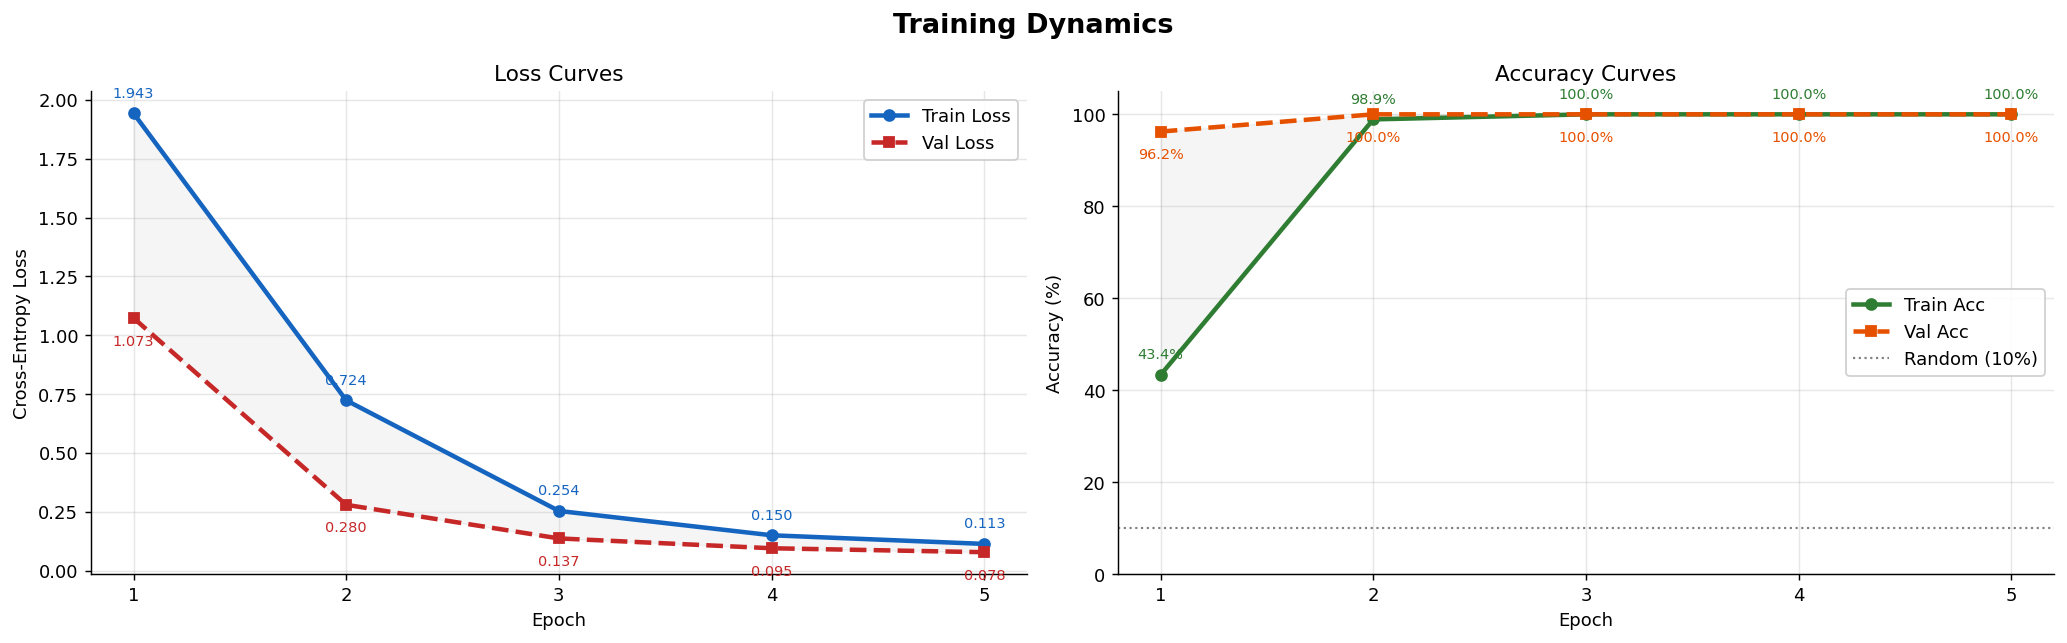

In [25]:
# ============================================================
# CELL 5: VISUALIZATION 1 — LOSS & ACCURACY CURVES
# ============================================================

epochs_x = list(range(1, NUM_EPOCHS+1))
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Training Dynamics", fontsize=15, fontweight="bold")

# --- Loss ---
ax = axes[0]
ax.plot(epochs_x, history["tr_loss"], "o-", lw=2.5,
        color="#1565C0", label="Train Loss")
ax.plot(epochs_x, history["va_loss"], "s--", lw=2.5,
        color="#C62828", label="Val Loss")
ax.fill_between(epochs_x, history["tr_loss"], history["va_loss"],
                alpha=0.08, color="gray")
for i, (tl, vl) in enumerate(zip(history["tr_loss"], history["va_loss"])):
    ax.annotate(f"{tl:.3f}", (epochs_x[i], tl),
                xytext=(0, 9), textcoords="offset points",
                fontsize=8, color="#1565C0", ha="center")
    ax.annotate(f"{vl:.3f}", (epochs_x[i], vl),
                xytext=(0, -15), textcoords="offset points",
                fontsize=8, color="#C62828", ha="center")
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Loss Curves"); ax.set_xticks(epochs_x)
ax.legend(framealpha=0.9)

# --- Accuracy ---
ax = axes[1]
ax.plot(epochs_x, history["tr_acc"], "o-", lw=2.5,
        color="#2E7D32", label="Train Acc")
ax.plot(epochs_x, history["va_acc"], "s--", lw=2.5,
        color="#E65100", label="Val Acc")
ax.axhline(10, color="gray", ls=":", lw=1.2, label="Random (10%)")
ax.fill_between(epochs_x, history["tr_acc"], history["va_acc"],
                alpha=0.08, color="gray")
for i, (ta, va) in enumerate(zip(history["tr_acc"], history["va_acc"])):
    ax.annotate(f"{ta:.1f}%", (epochs_x[i], ta),
                xytext=(0, 9), textcoords="offset points",
                fontsize=8, color="#2E7D32", ha="center")
    ax.annotate(f"{va:.1f}%", (epochs_x[i], va),
                xytext=(0, -15), textcoords="offset points",
                fontsize=8, color="#E65100", ha="center")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy Curves"); ax.set_xticks(epochs_x)
ax.set_ylim(0, 105); ax.legend(framealpha=0.9)

plt.tight_layout()
plt.savefig("viz1_loss_acc.png", dpi=150, bbox_inches="tight")
plt.show()

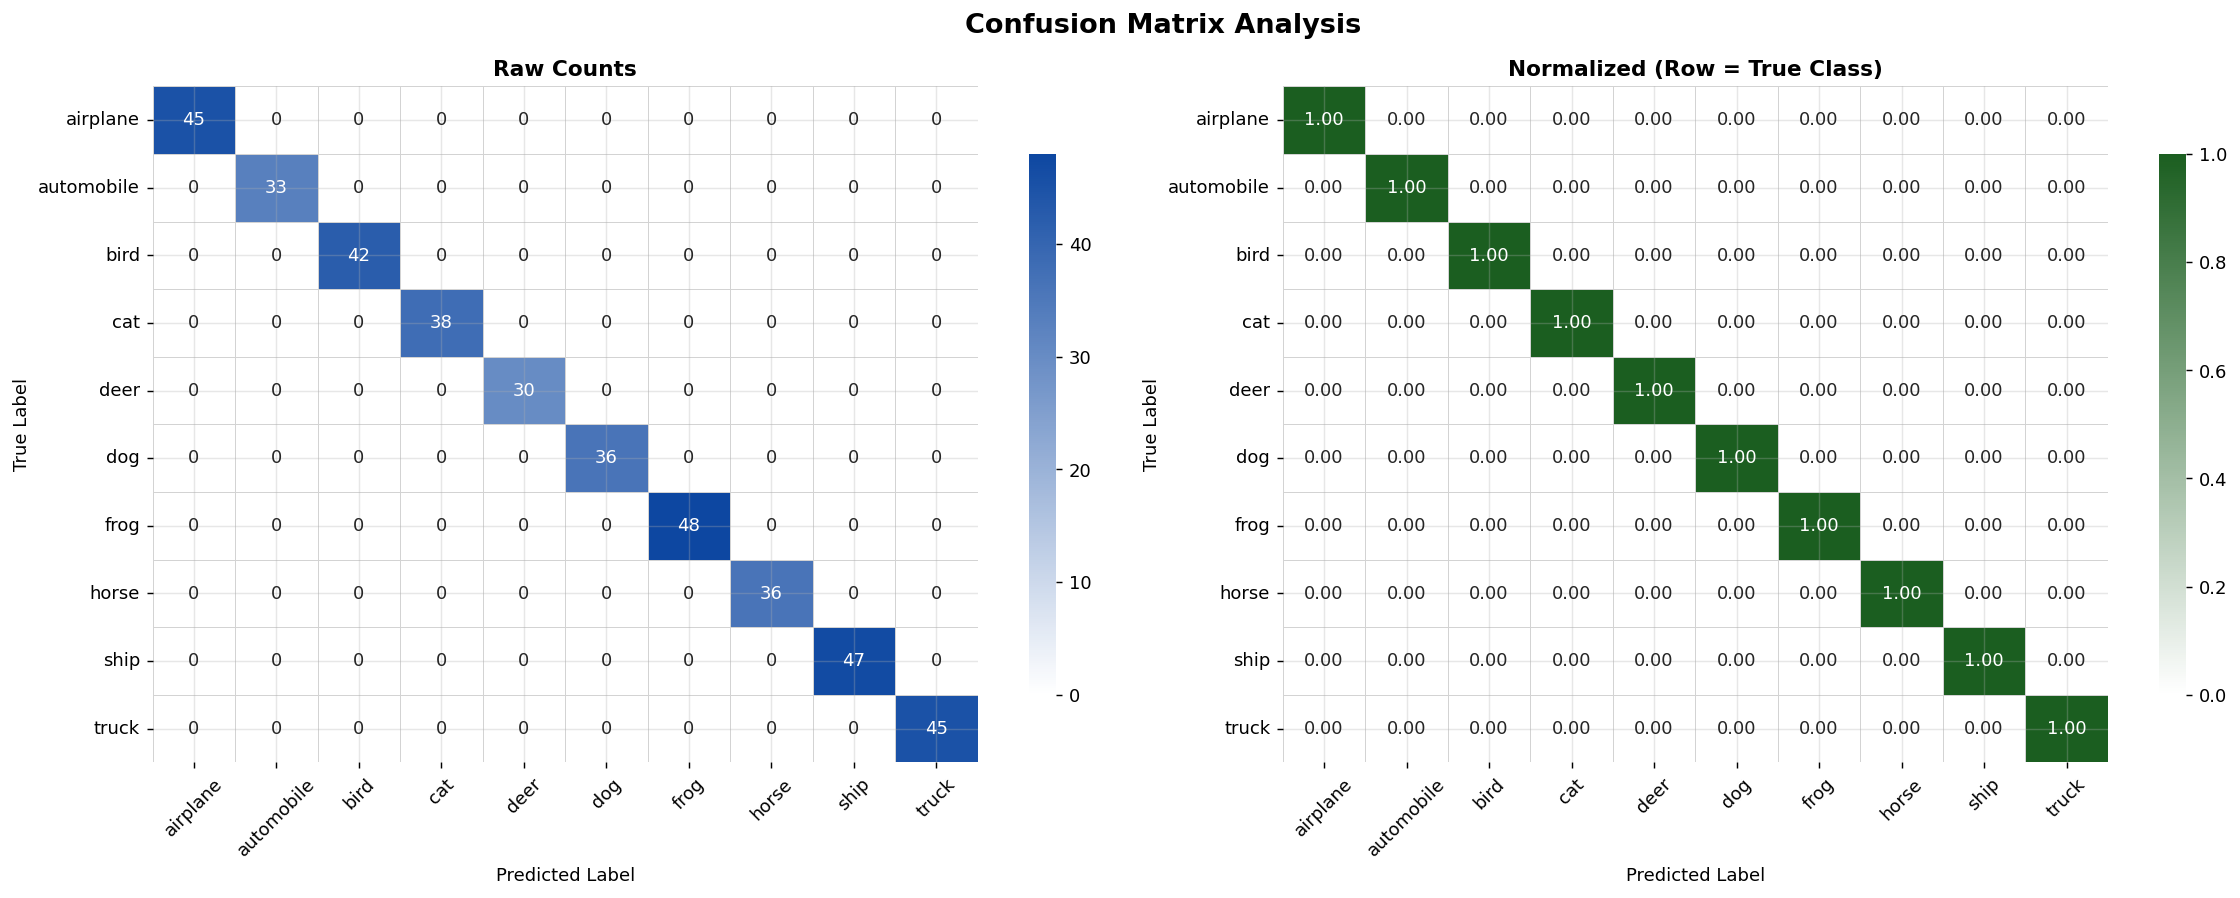

In [26]:
# ============================================================
# CELL 6: VISUALIZATION 2 — CONFUSION MATRIX (HEATMAP)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Confusion Matrix Analysis", fontsize=15, fontweight="bold")

# --- Raw counts ---
ax = axes[0]
cmap_blue = LinearSegmentedColormap.from_list(
    "blue_white", ["#FFFFFF", "#0D47A1"])
sns.heatmap(cm, annot=True, fmt="d", cmap=cmap_blue,
            xticklabels=CIFAR10_CLASSES,
            yticklabels=CIFAR10_CLASSES,
            linewidths=0.4, linecolor="lightgray",
            ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Raw Counts", fontweight="bold")
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
ax.tick_params(axis="x", rotation=45)

# --- Normalized (recall per class) ---
ax = axes[1]
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cmap_green = LinearSegmentedColormap.from_list(
    "green_white", ["#FFFFFF", "#1B5E20"])
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap=cmap_green,
            xticklabels=CIFAR10_CLASSES,
            yticklabels=CIFAR10_CLASSES,
            linewidths=0.4, linecolor="lightgray",
            ax=ax, cbar_kws={"shrink": 0.8},
            vmin=0, vmax=1)
ax.set_title("Normalized (Row = True Class)", fontweight="bold")
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("viz2_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

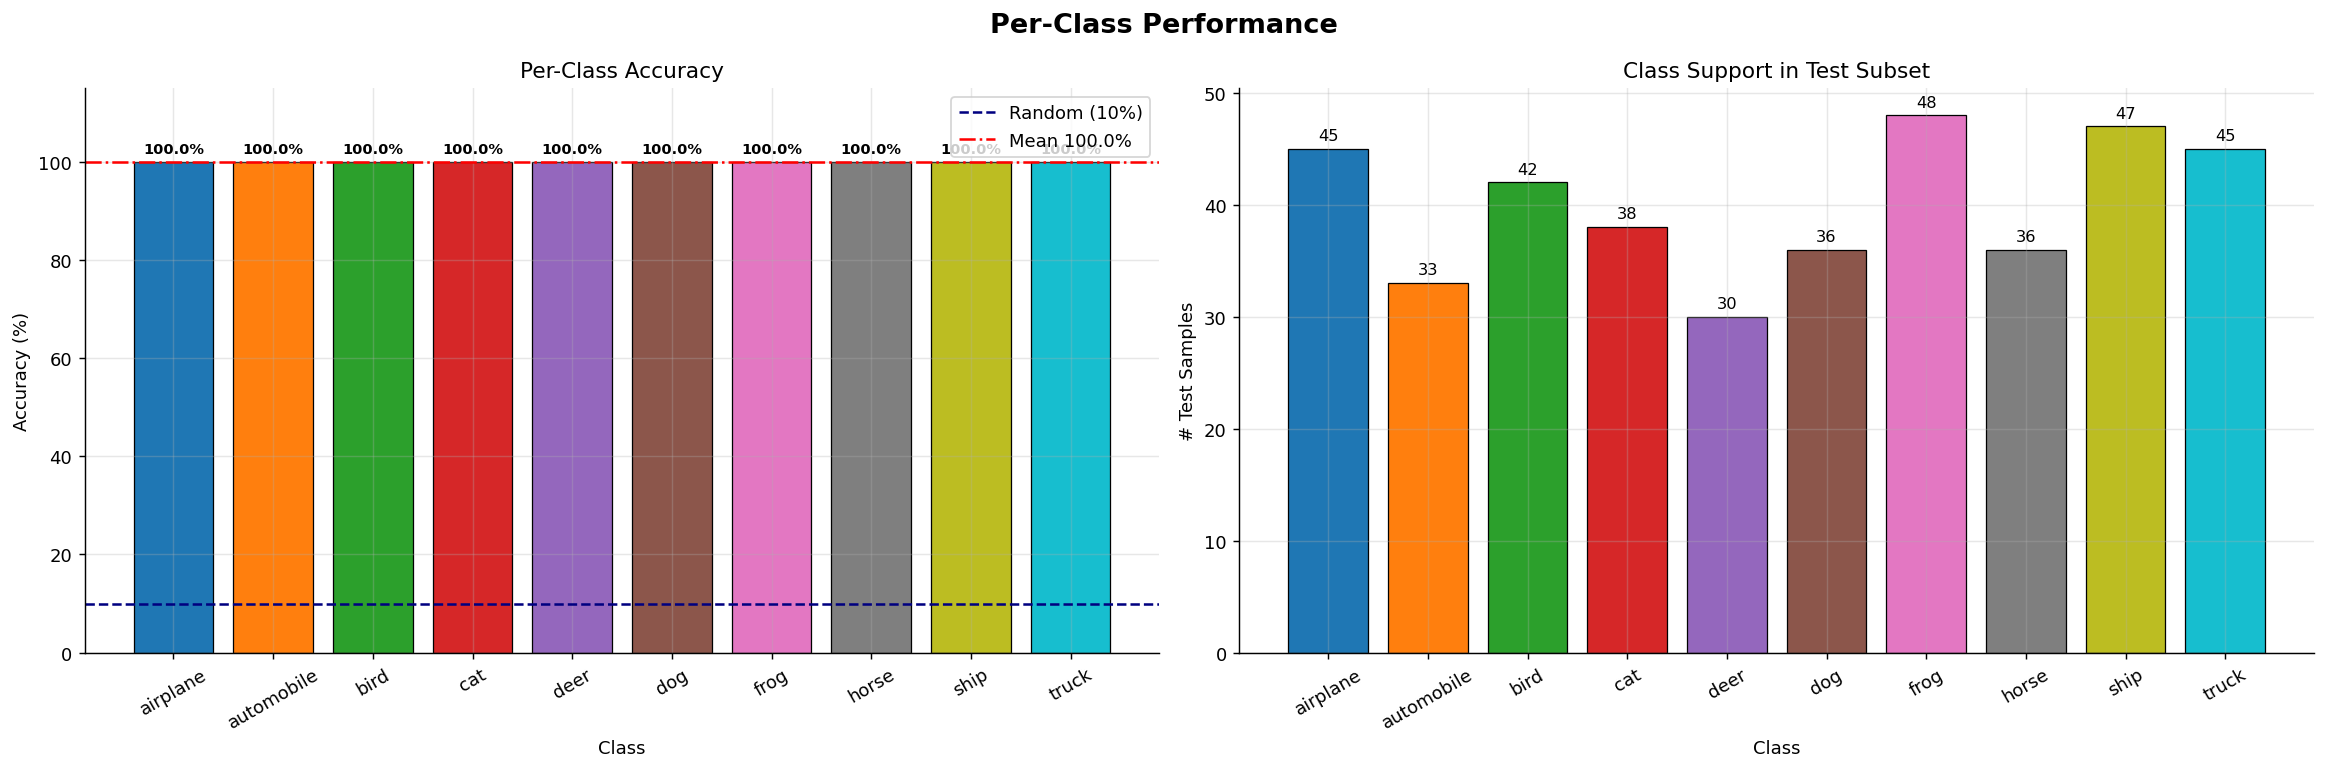

In [27]:
# ============================================================
# CELL 7: VISUALIZATION 3 — PER-CLASS ACCURACY BAR CHART
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Per-Class Performance", fontsize=15, fontweight="bold")

# --- Accuracy bar ---
ax = axes[0]
bars = ax.bar(CIFAR10_CLASSES, per_class_acc,
              color=CLASS_COLORS, edgecolor="black", lw=0.7)
ax.axhline(10, color="navy", ls="--", lw=1.4, label="Random (10%)")
ax.axhline(np.mean(per_class_acc), color="red", ls="-.",
           lw=1.4, label=f"Mean {np.mean(per_class_acc):.1f}%")
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+1.2,
            f"{acc:.1f}%", ha="center", va="bottom",
            fontsize=8, fontweight="bold")
ax.set_ylim(0, 115); ax.set_xlabel("Class"); ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Class Accuracy"); ax.tick_params(axis="x", rotation=30)
ax.legend()

# --- Support (sample count) bar ---
ax = axes[1]
support = [cm[c].sum() for c in range(NUM_CLASSES)]
ax.bar(CIFAR10_CLASSES, support, color=CLASS_COLORS,
       edgecolor="black", lw=0.7)
for i, s in enumerate(support):
    ax.text(i, s + 0.5, str(s), ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Class"); ax.set_ylabel("# Test Samples")
ax.set_title("Class Support in Test Subset")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("viz3_perclass.png", dpi=150, bbox_inches="tight")
plt.show()

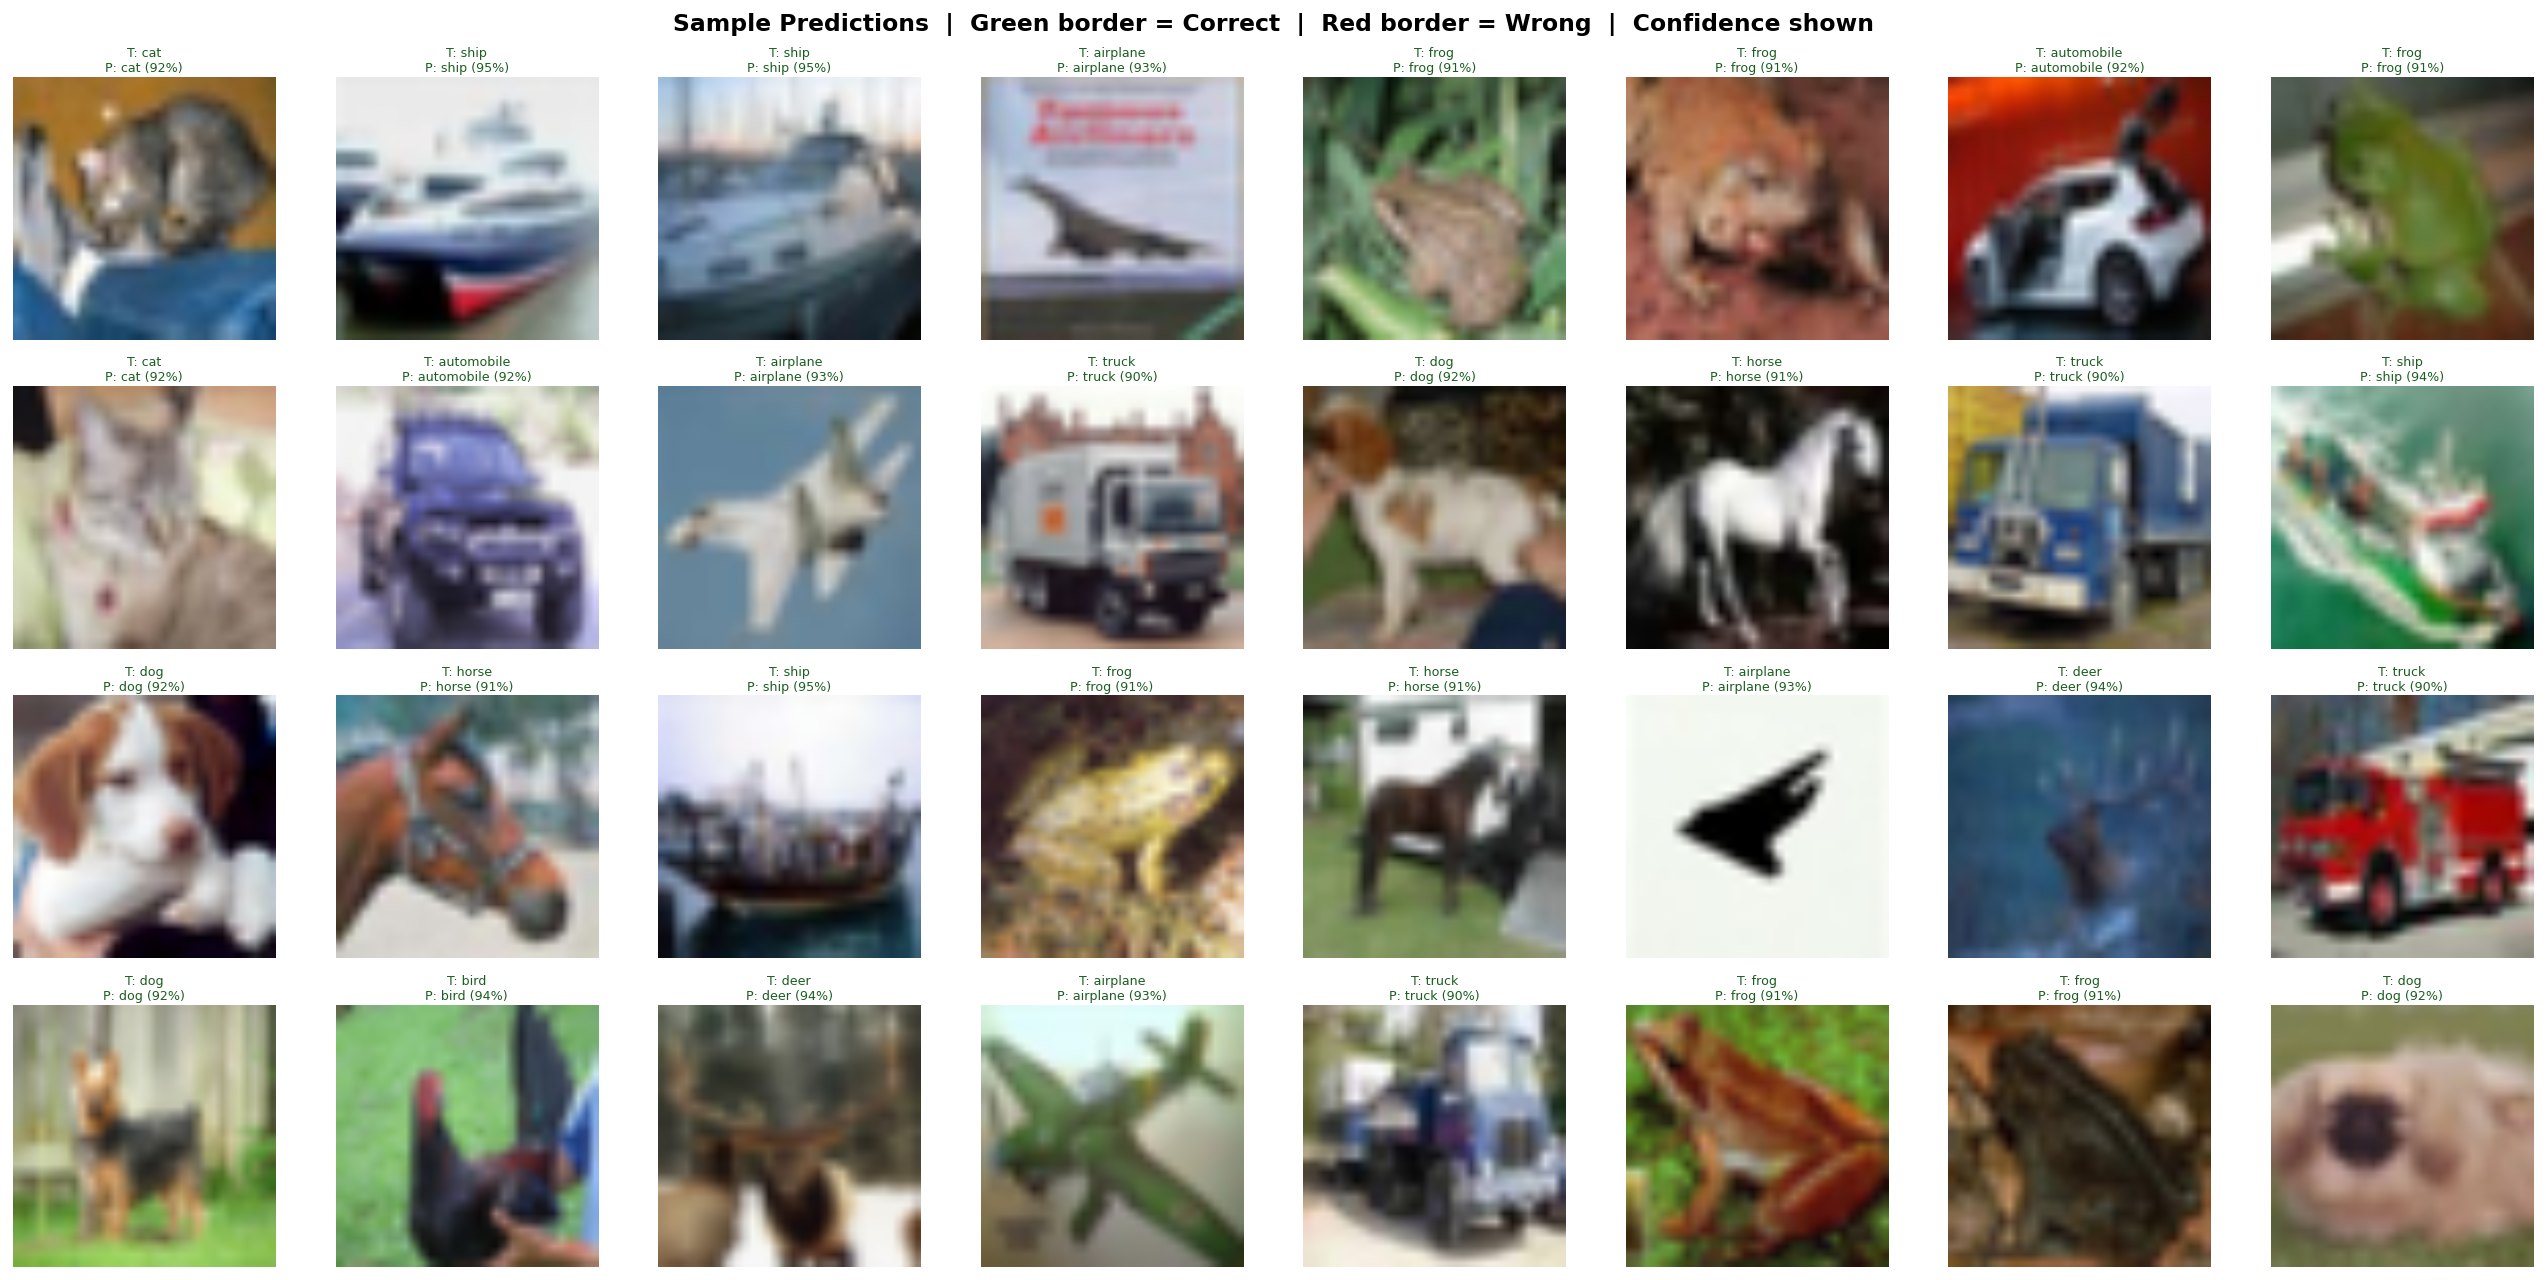

In [28]:
# ============================================================
# CELL 8: VISUALIZATION 4 — SAMPLE PREDICTIONS GRID
# ============================================================

def denormalize(t):
    x = t.clone()
    for c in range(3): x[c] = x[c]*STD[c]+MEAN[c]
    return x.clamp(0,1)

# Collect 32 test images with predictions
model.eval()
sample_imgs, sample_true, sample_pred, sample_conf = [], [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs_d = imgs.to(DEVICE)
        toks   = torch.stack([caption_to_tokens(l.item(), VOCAB)
                               for l in labels]).to(DEVICE)
        logits = model(imgs_d, toks)
        probs  = F.softmax(logits, dim=1)
        preds  = probs.argmax(1)
        confs  = probs.max(1).values

        for i in range(imgs.size(0)):
            sample_imgs.append(imgs[i])
            sample_true.append(labels[i].item())
            sample_pred.append(preds[i].item())
            sample_conf.append(confs[i].item())
        if len(sample_imgs) >= 32: break

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
fig.suptitle("Sample Predictions  |  Green border = Correct  |  "
             "Red border = Wrong  |  Confidence shown",
             fontsize=13, fontweight="bold")

for idx, ax in enumerate(axes.flat):
    if idx >= 32: ax.axis("off"); continue
    img_np = denormalize(sample_imgs[idx]).permute(1,2,0).numpy()
    ax.imshow(img_np, interpolation="bilinear")
    ax.axis("off")
    correct = (sample_true[idx] == sample_pred[idx])
    color   = "#1B5E20" if correct else "#B71C1C"
    for spine in ["top","bottom","left","right"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color(color)
        ax.spines[spine].set_linewidth(3)
    ax.set_title(
        f"T: {CIFAR10_CLASSES[sample_true[idx]]}\n"
        f"P: {CIFAR10_CLASSES[sample_pred[idx]]} "
        f"({sample_conf[idx]*100:.0f}%)",
        fontsize=7, color=color, pad=3
    )

plt.tight_layout()
plt.savefig("viz4_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

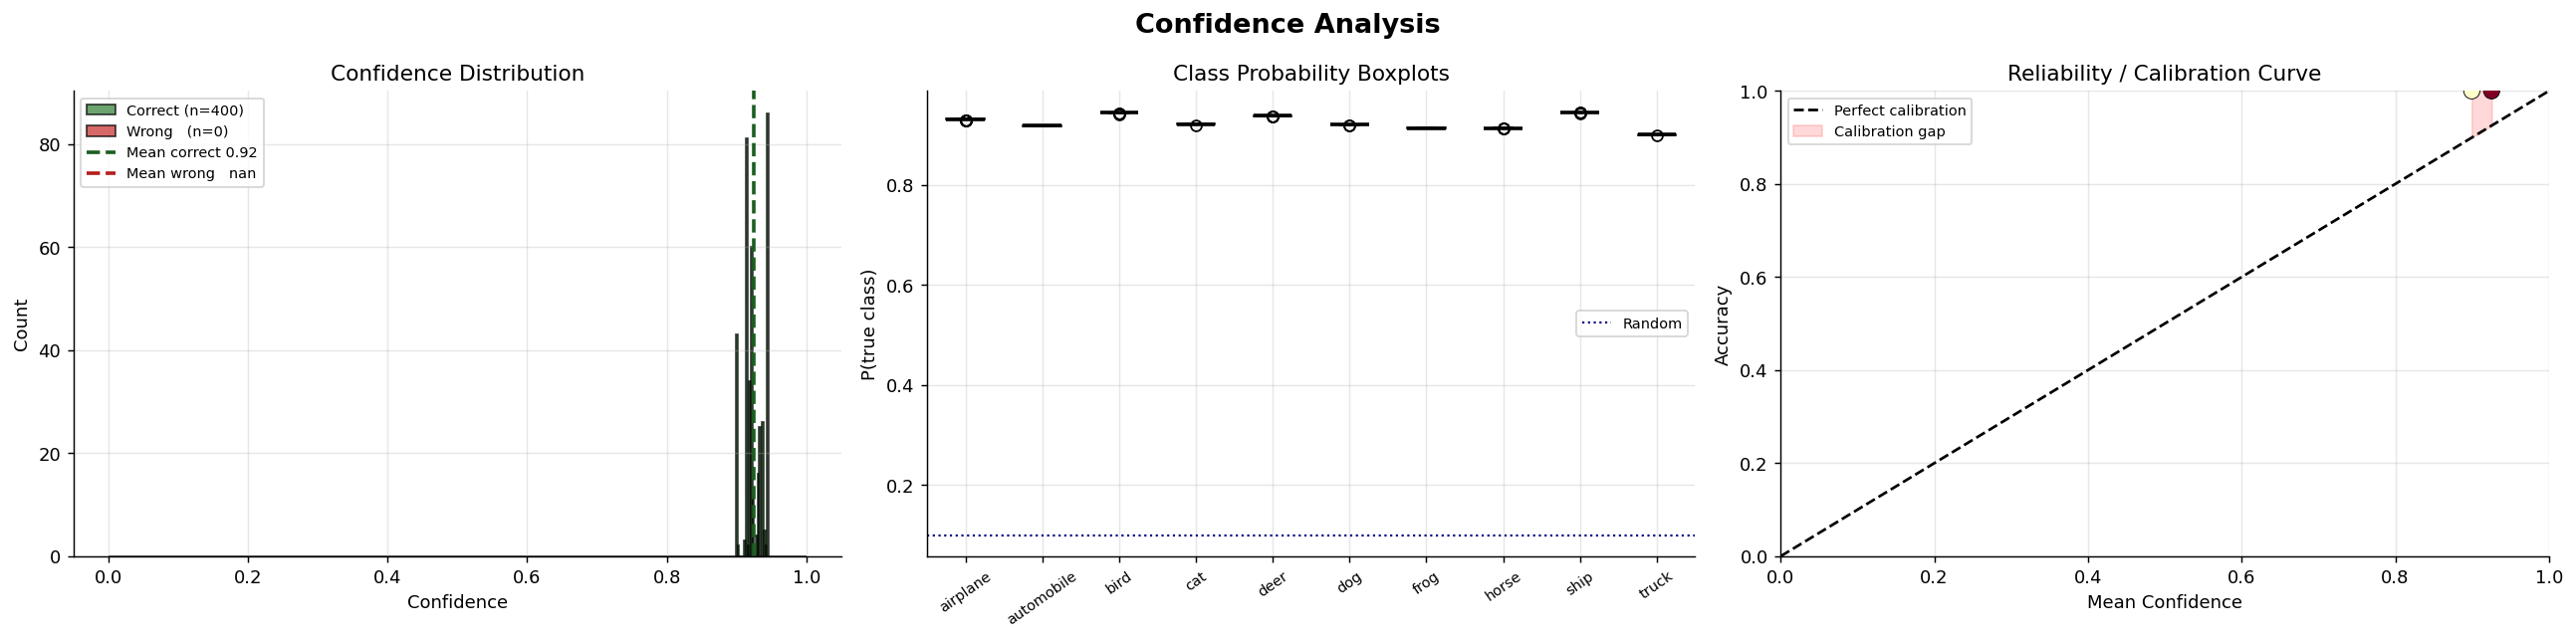

In [29]:
# ============================================================
# CELL 9: VISUALIZATION 5 — CONFIDENCE DISTRIBUTION
# ============================================================

model.eval()
all_confs_correct, all_confs_wrong = [], []
all_probs_matrix = np.zeros((SUBSET_TEST, NUM_CLASSES))
ptr = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs_d = imgs.to(DEVICE)
        toks   = torch.stack([caption_to_tokens(l.item(), VOCAB)
                               for l in labels]).to(DEVICE)
        probs  = F.softmax(model(imgs_d, toks), dim=1).cpu().numpy()
        preds  = probs.argmax(1)
        bs     = imgs.size(0)
        all_probs_matrix[ptr:ptr+bs] = probs
        ptr   += bs
        for i in range(bs):
            conf = probs[i].max()
            if preds[i] == labels[i].item():
                all_confs_correct.append(conf)
            else:
                all_confs_wrong.append(conf)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Confidence Analysis", fontsize=15, fontweight="bold")

# --- Histogram: correct vs wrong ---
ax = axes[0]
ax.hist(all_confs_correct, bins=20, color="#2E7D32",
        alpha=0.7, label=f"Correct (n={len(all_confs_correct)})",
        edgecolor="black", lw=0.5)
ax.hist(all_confs_wrong,   bins=20, color="#C62828",
        alpha=0.7, label=f"Wrong   (n={len(all_confs_wrong)})",
        edgecolor="black", lw=0.5)
ax.axvline(np.mean(all_confs_correct), color="#1B5E20",
           ls="--", lw=2, label=f"Mean correct {np.mean(all_confs_correct):.2f}")
ax.axvline(np.mean(all_confs_wrong),   color="#B71C1C",
           ls="--", lw=2, label=f"Mean wrong   {np.mean(all_confs_wrong):.2f}")
ax.set_xlabel("Confidence"); ax.set_ylabel("Count")
ax.set_title("Confidence Distribution")
ax.legend(fontsize=8)

# --- Box plot per class ---
ax = axes[1]
box_data = [all_probs_matrix[
                [i for i,l in enumerate(final_labels) if l==c],
                c].tolist()
            for c in range(NUM_CLASSES)]
bp = ax.boxplot(box_data, patch_artist=True, notch=False,
                medianprops=dict(color="black", lw=2))
for patch, color in zip(bp["boxes"], CLASS_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax.set_xticklabels(CIFAR10_CLASSES, rotation=35, fontsize=8)
ax.set_ylabel("P(true class)"); ax.set_title("Class Probability Boxplots")
ax.axhline(0.1, color="navy", ls=":", lw=1.2, label="Random")
ax.legend(fontsize=8)

# --- Calibration curve ---
ax = axes[2]
bins      = np.linspace(0, 1, 11)
bin_accs, bin_confs, bin_counts = [], [], []
all_confs_all = all_probs_matrix.max(1)
all_correct   = (all_probs_matrix.argmax(1)
                 == np.array(final_labels[:ptr])).astype(float)

for b_lo, b_hi in zip(bins[:-1], bins[1:]):
    mask = (all_confs_all >= b_lo) & (all_confs_all < b_hi)
    if mask.sum() > 0:
        bin_accs.append(all_correct[mask].mean())
        bin_confs.append(all_confs_all[mask].mean())
        bin_counts.append(mask.sum())

ax.plot([0,1],[0,1], "k--", lw=1.5, label="Perfect calibration")
ax.scatter(bin_confs, bin_accs, c=bin_counts,
           cmap="YlOrRd", s=80, zorder=5, edgecolors="black", lw=0.5)
ax.fill_between(bin_confs, bin_accs, bin_confs,
                alpha=0.15, color="red", label="Calibration gap")
ax.set_xlabel("Mean Confidence"); ax.set_ylabel("Accuracy")
ax.set_title("Reliability / Calibration Curve")
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("viz5_confidence.png", dpi=150, bbox_inches="tight")
plt.show()

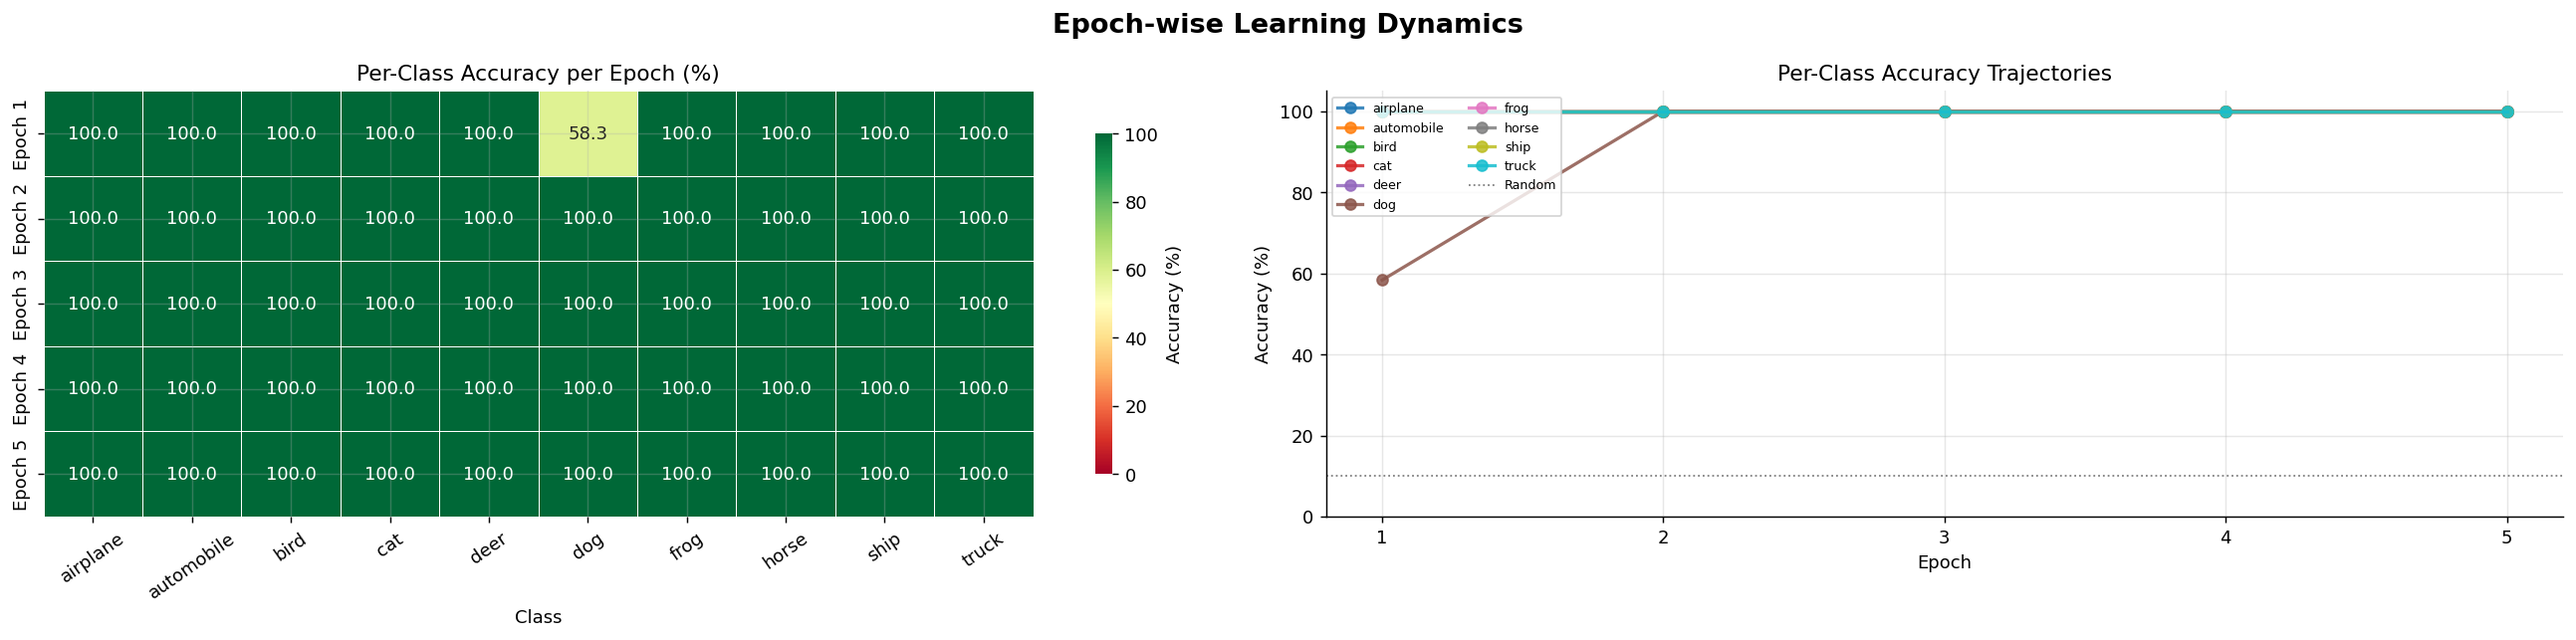

In [30]:
# ============================================================
# CELL 10: VISUALIZATION 6 — EPOCH-WISE ACCURACY HEATMAP
# ============================================================

epoch_class_acc = np.zeros((NUM_EPOCHS, NUM_CLASSES))

for ep in range(NUM_EPOCHS):
    preds_ep  = history["v_preds"][ep]
    labels_ep = history["v_lbls"][ep]
    cm_ep     = confusion_matrix(labels_ep, preds_ep,
                                  labels=list(range(NUM_CLASSES)))
    for c in range(NUM_CLASSES):
        if cm_ep[c].sum() > 0:
            epoch_class_acc[ep, c] = 100 * cm_ep[c,c] / cm_ep[c].sum()

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
fig.suptitle("Epoch-wise Learning Dynamics", fontsize=15, fontweight="bold")

# --- Heatmap ---
ax = axes[0]
sns.heatmap(epoch_class_acc,
            xticklabels=CIFAR10_CLASSES,
            yticklabels=[f"Epoch {e}" for e in range(1, NUM_EPOCHS+1)],
            annot=True, fmt=".1f",
            cmap="RdYlGn", vmin=0, vmax=100,
            linewidths=0.5, linecolor="white",
            cbar_kws={"label":"Accuracy (%)","shrink":0.8},
            ax=ax)
ax.set_title("Per-Class Accuracy per Epoch (%)")
ax.set_xlabel("Class"); ax.tick_params(axis="x", rotation=35)

# --- Line plot: class accuracy trajectories ---
ax = axes[1]
for c in range(NUM_CLASSES):
    ax.plot(range(1, NUM_EPOCHS+1), epoch_class_acc[:, c],
            "o-", lw=1.8, color=CLASS_COLORS[c],
            label=CIFAR10_CLASSES[c], alpha=0.85)
ax.axhline(10, color="gray", ls=":", lw=1, label="Random")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Class Accuracy Trajectories")
ax.set_xticks(range(1, NUM_EPOCHS+1))
ax.legend(fontsize=7, ncol=2, loc="upper left")
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig("viz6_epoch_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

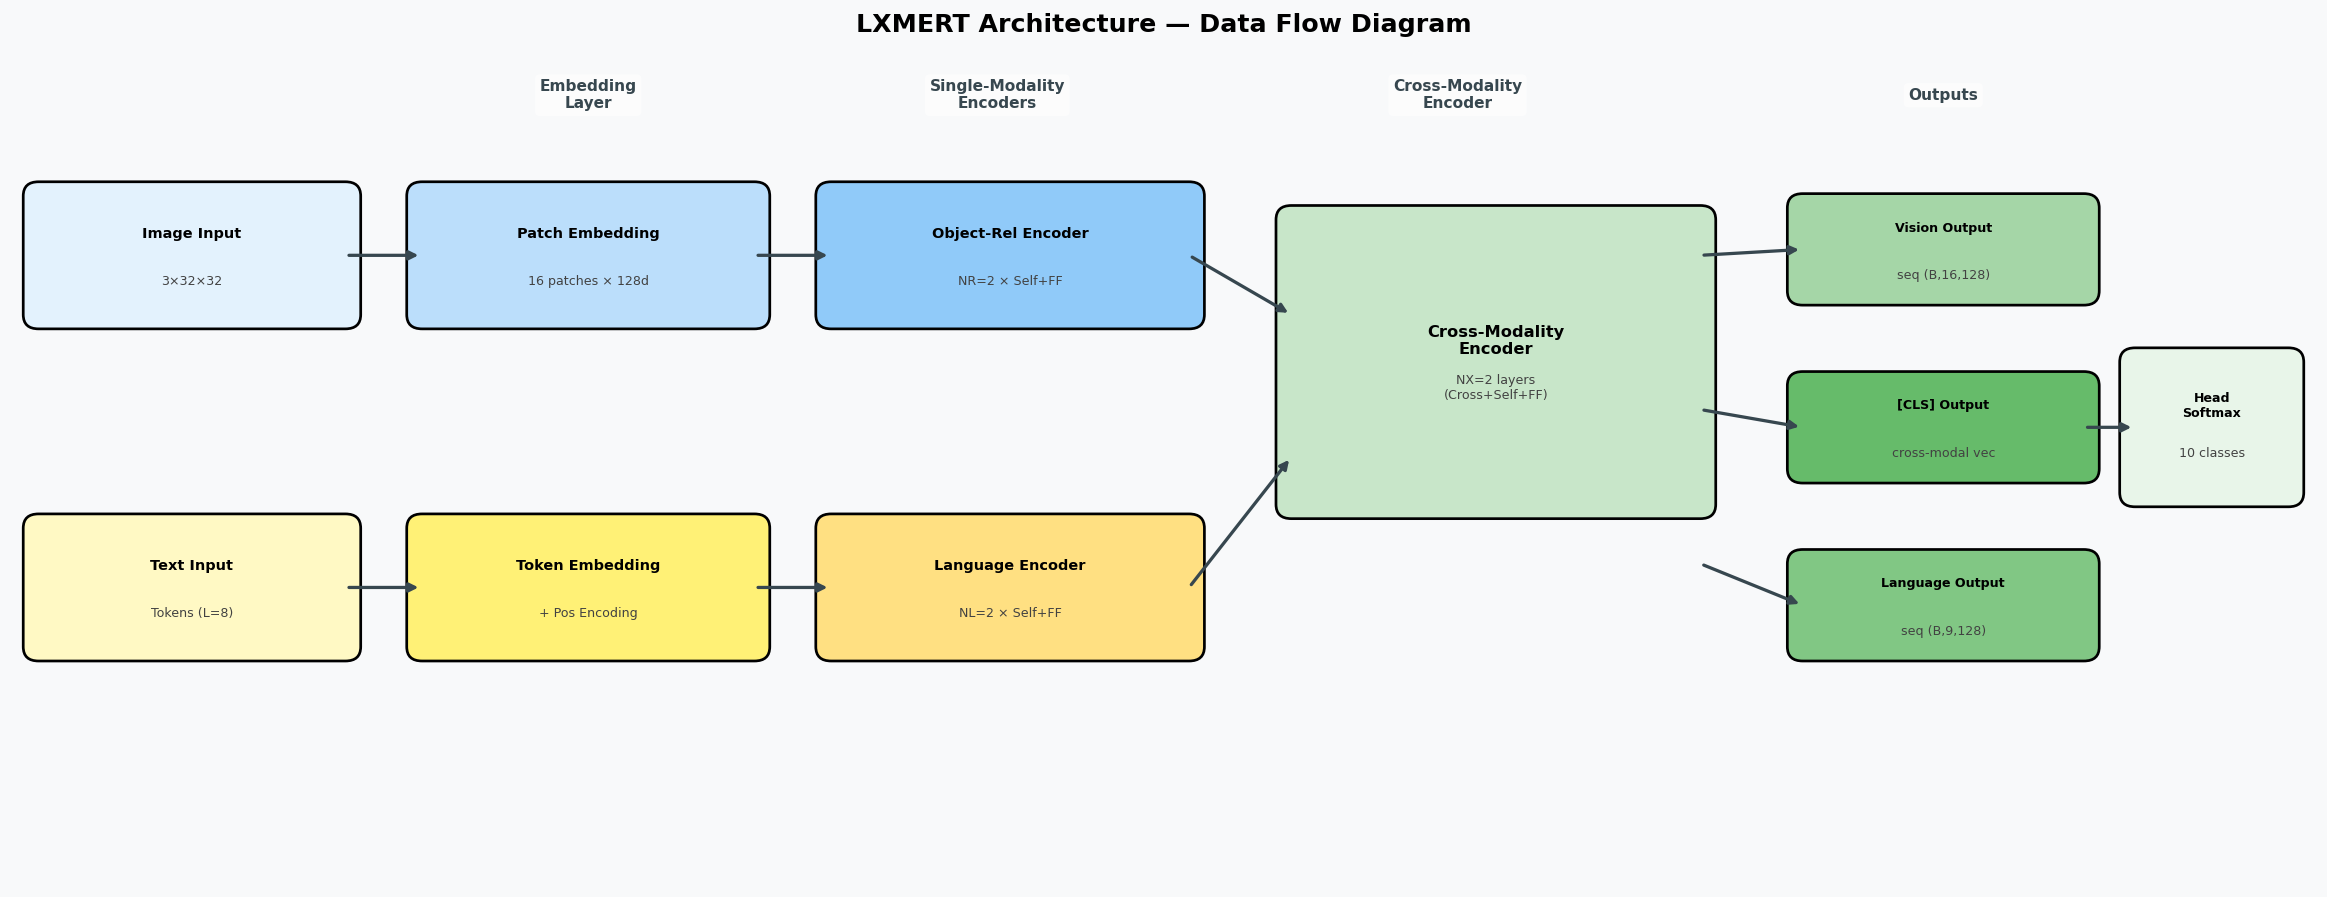

In [31]:
# ============================================================
# CELL 11: VISUALIZATION 7 — ARCHITECTURE DIAGRAM (SVG-STYLE)
# ============================================================

fig, ax = plt.subplots(figsize=(18, 7))
ax.set_xlim(0, 18); ax.set_ylim(0, 7); ax.axis("off")
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("#F8F9FA")
ax.set_title("LXMERT Architecture — Data Flow Diagram",
             fontsize=14, fontweight="bold", pad=12)

def box(ax, x, y, w, h, color, label, sub="", fontsize=9):
    rect = mpatches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.12", lw=1.5,
        edgecolor="black", facecolor=color, zorder=3)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h/2 + (0.18 if sub else 0),
            label, ha="center", va="center",
            fontsize=fontsize, fontweight="bold", zorder=4)
    if sub:
        ax.text(x+w/2, y+h/2 - 0.22, sub,
                ha="center", va="center",
                fontsize=7, color="#424242", zorder=4)

def arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle="-|>", color="#37474F",
                                lw=1.8), zorder=5)

# --- Input layer ---
box(ax, 0.2, 4.8, 2.4, 1.0, "#E3F2FD", "Image Input",  "3×32×32",  8)
box(ax, 0.2, 2.0, 2.4, 1.0, "#FFF9C4", "Text Input",   "Tokens (L=8)", 8)

# --- Embedding layer ---
box(ax, 3.2, 4.8, 2.6, 1.0, "#BBDEFB", "Patch Embedding","16 patches × 128d", 8)
box(ax, 3.2, 2.0, 2.6, 1.0, "#FFF176", "Token Embedding","+ Pos Encoding", 8)

# --- Single modality encoders ---
box(ax, 6.4, 4.8, 2.8, 1.0, "#90CAF9",
    "Object-Rel Encoder", f"NR={N_VISION} × Self+FF", 8)
box(ax, 6.4, 2.0, 2.8, 1.0, "#FFE082",
    "Language Encoder",   f"NL={N_LANG} × Self+FF",   8)

# --- Cross-modality encoder ---
box(ax, 10.0, 3.2, 3.2, 2.4, "#C8E6C9",
    "Cross-Modality\nEncoder",
    f"NX={N_CROSS} layers\n(Cross+Self+FF)", 9)

# --- Outputs ---
box(ax, 14.0, 5.0, 2.2, 0.7, "#A5D6A7", "Vision Output",    "seq (B,16,128)", 7)
box(ax, 14.0, 3.5, 2.2, 0.7, "#66BB6A", "[CLS] Output",     "cross-modal vec", 7)
box(ax, 14.0, 2.0, 2.2, 0.7, "#81C784", "Language Output",  "seq (B,9,128)",  7)

# --- Classifier ---
box(ax, 16.6, 3.3, 1.2, 1.1, "#E8F5E9", "Head\nSoftmax", "10 classes", 7)

# --- Arrows ---
arrow(ax, 2.6, 5.3, 3.2, 5.3)
arrow(ax, 2.6, 2.5, 3.2, 2.5)
arrow(ax, 5.8, 5.3, 6.4, 5.3)
arrow(ax, 5.8, 2.5, 6.4, 2.5)
arrow(ax, 9.2, 5.3, 10.0, 4.8)
arrow(ax, 9.2, 2.5, 10.0, 3.6)
arrow(ax, 13.2, 5.3, 14.0, 5.35)
arrow(ax, 13.2, 4.0, 14.0, 3.85)
arrow(ax, 13.2, 2.7, 14.0, 2.35)
arrow(ax, 16.2, 3.85, 16.6, 3.85)

# --- Layer labels ---
for x, label, color in [
    (3.2, "Embedding\nLayer",      "#E3F2FD"),
    (6.4, "Single-Modality\nEncoders", "#FFF9C4"),
    (10.0,"Cross-Modality\nEncoder",   "#C8E6C9"),
    (14.0,"Outputs",               "#E8F5E9"),
]:
    ax.text(x + (1.3 if x < 14 else 1.1), 6.65, label,
            ha="center", va="center", fontsize=8.5,
            fontweight="bold", color="#37474F",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white", alpha=0.6, edgecolor="none"))

plt.tight_layout()
plt.savefig("viz7_architecture.png", dpi=150, bbox_inches="tight")
plt.show()

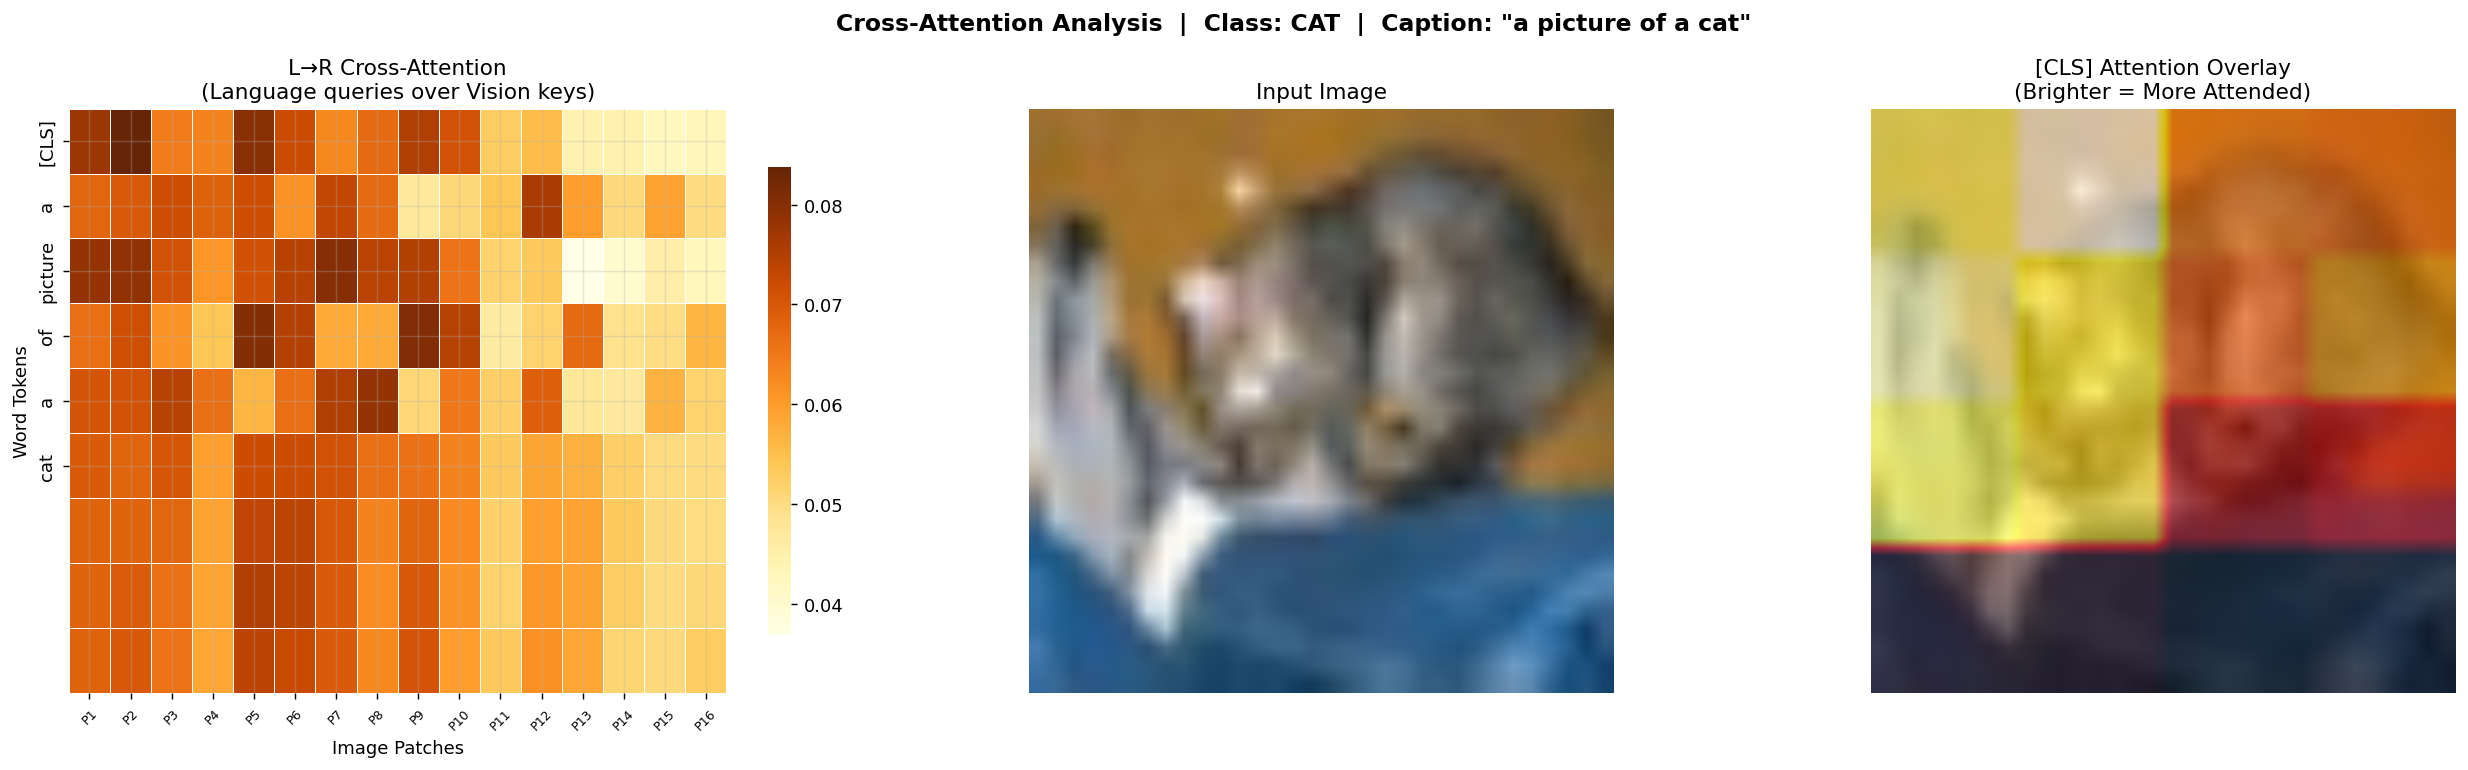

In [32]:
# ============================================================
# CELL 12: VISUALIZATION 8 — ATTENTION WEIGHT HEATMAP
# ============================================================
# We hook into the first CrossModalityLayer to capture actual
# cross-attention weights between patches and word tokens.
# ============================================================

attn_weights_store = {}

def hook_cross_attn(module, inp, out):
    # MultiheadAttention returns (output, attn_weights)
    attn_weights_store["L2R"] = out[1].detach().cpu()

# Register hook on first cross-modality layer's L→R attention
hook = model.cross_enc.layers[0].xL2R.register_forward_hook(
    hook_cross_attn)

model.eval()
with torch.no_grad():
    imgs_h, labels_h = next(iter(test_loader))
    imgs_h   = imgs_h[:1].to(DEVICE)
    toks_h   = caption_to_tokens(labels_h[0].item(), VOCAB).unsqueeze(0).to(DEVICE)
    cls_tok  = model.cls_token.expand(1, -1, -1)
    tok_emb  = torch.cat([cls_tok, model.tok_emb(toks_h)], dim=1)
    tok_emb  = model.pe_lang(tok_emb)
    h0       = model.lang_enc(model.drop(tok_emb))
    vis_emb  = model.pe_vis(model.patch_emb(imgs_h))
    v0       = model.vis_enc(model.drop(vis_emb))
    _        = model.cross_enc.layers[0](h0, v0)

hook.remove()

attn = attn_weights_store["L2R"][0]   # (n_words+1, n_patches)
true_cls = labels_h[0].item()

caption = random.choice(CAPTION_TEMPLATES).format(
              CIFAR10_CLASSES[true_cls])
word_labels = ["[CLS]"] + caption.split()
word_labels  = word_labels[:attn.shape[0]]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f"Cross-Attention Analysis  |  Class: "
             f"{CIFAR10_CLASSES[true_cls].upper()}  |  "
             f"Caption: \"{caption}\"",
             fontsize=13, fontweight="bold")

# --- Heatmap: word → patch attention ---
ax = axes[0]
patch_labels = [f"P{i+1}" for i in range(attn.shape[1])]
sns.heatmap(attn.numpy(),
            xticklabels=patch_labels,
            yticklabels=word_labels,
            cmap="YlOrBr", ax=ax,
            linewidths=0.3, linecolor="white",
            cbar_kws={"shrink": 0.8})
ax.set_title("L→R Cross-Attention\n(Language queries over Vision keys)")
ax.set_xlabel("Image Patches"); ax.set_ylabel("Word Tokens")
ax.tick_params(axis="x", rotation=45, labelsize=7)

# --- Original image ---
ax = axes[1]
img_disp = denormalize(imgs_h[0].cpu()).permute(1,2,0).numpy()
ax.imshow(img_disp, interpolation="bilinear")
ax.set_title("Input Image")
ax.axis("off")

# --- Attention rollout: overlay on image ---
ax = axes[2]
cls_attn = attn[0].numpy()        # [CLS] attention over patches
cls_attn = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-8)
n_side   = int(math.sqrt(attn.shape[1]))
attn_map = cls_attn[:n_side*n_side].reshape(n_side, n_side)
# Upsample to image size
attn_up  = np.kron(attn_map, np.ones((32//n_side, 32//n_side)))
ax.imshow(img_disp, interpolation="bilinear")
ax.imshow(attn_up, cmap="hot", alpha=0.55, interpolation="bilinear")
ax.set_title("[CLS] Attention Overlay\n(Brighter = More Attended)")
ax.axis("off")

plt.tight_layout()
plt.savefig("viz8_attention.png", dpi=150, bbox_inches="tight")
plt.show()

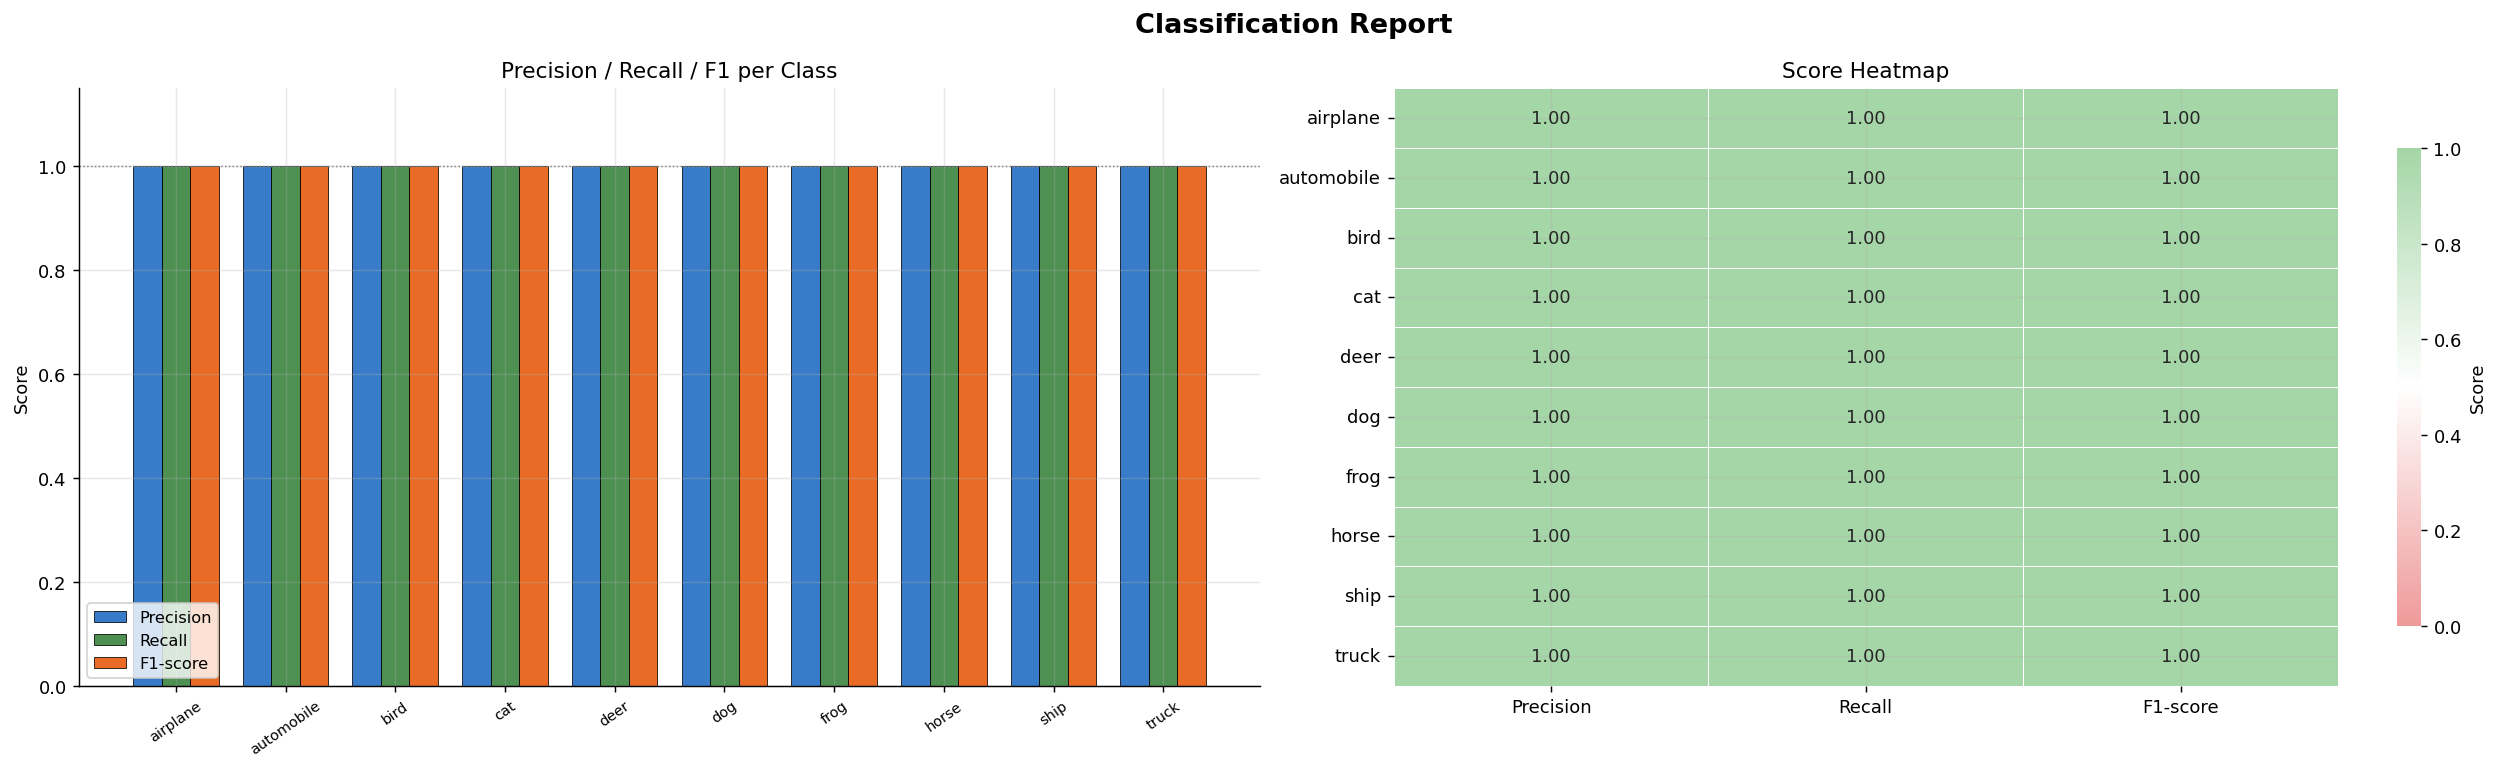

In [33]:
# ============================================================
# CELL 13: VISUALIZATION 9 — CLASSIFICATION REPORT TABLE
# ============================================================

report = classification_report(final_labels, final_preds,
                                target_names=CIFAR10_CLASSES,
                                output_dict=True)

metrics  = ["precision","recall","f1-score"]
data_mat = np.array([[report[c][m] for m in metrics]
                      for c in CIFAR10_CLASSES])

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle("Classification Report", fontsize=15, fontweight="bold")

# --- Grouped bar chart ---
ax = axes[0]
x   = np.arange(NUM_CLASSES)
w   = 0.26
colors_bar = ["#1565C0","#2E7D32","#E65100"]
for i, (metric, color) in enumerate(zip(metrics, colors_bar)):
    vals = data_mat[:, i]
    bars = ax.bar(x + i*w - w, vals, w,
                  label=metric.capitalize(),
                  color=color, alpha=0.85, edgecolor="black", lw=0.5)

ax.set_xticks(x); ax.set_xticklabels(CIFAR10_CLASSES, rotation=35, fontsize=8)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score"); ax.legend(fontsize=9)
ax.set_title("Precision / Recall / F1 per Class")
ax.axhline(1.0, color="gray", ls=":", lw=0.8)

# --- Heatmap table ---
ax = axes[1]
cmap_bwr = LinearSegmentedColormap.from_list(
    "rwg", ["#EF9A9A","#FFFFFF","#A5D6A7"])
sns.heatmap(data_mat,
            xticklabels=[m.capitalize() for m in metrics],
            yticklabels=CIFAR10_CLASSES,
            annot=True, fmt=".2f",
            cmap=cmap_bwr, vmin=0, vmax=1,
            linewidths=0.5, linecolor="white",
            cbar_kws={"label":"Score","shrink":0.8},
            ax=ax)
ax.set_title("Score Heatmap")

plt.tight_layout()
plt.savefig("viz9_report.png", dpi=150, bbox_inches="tight")
plt.show()

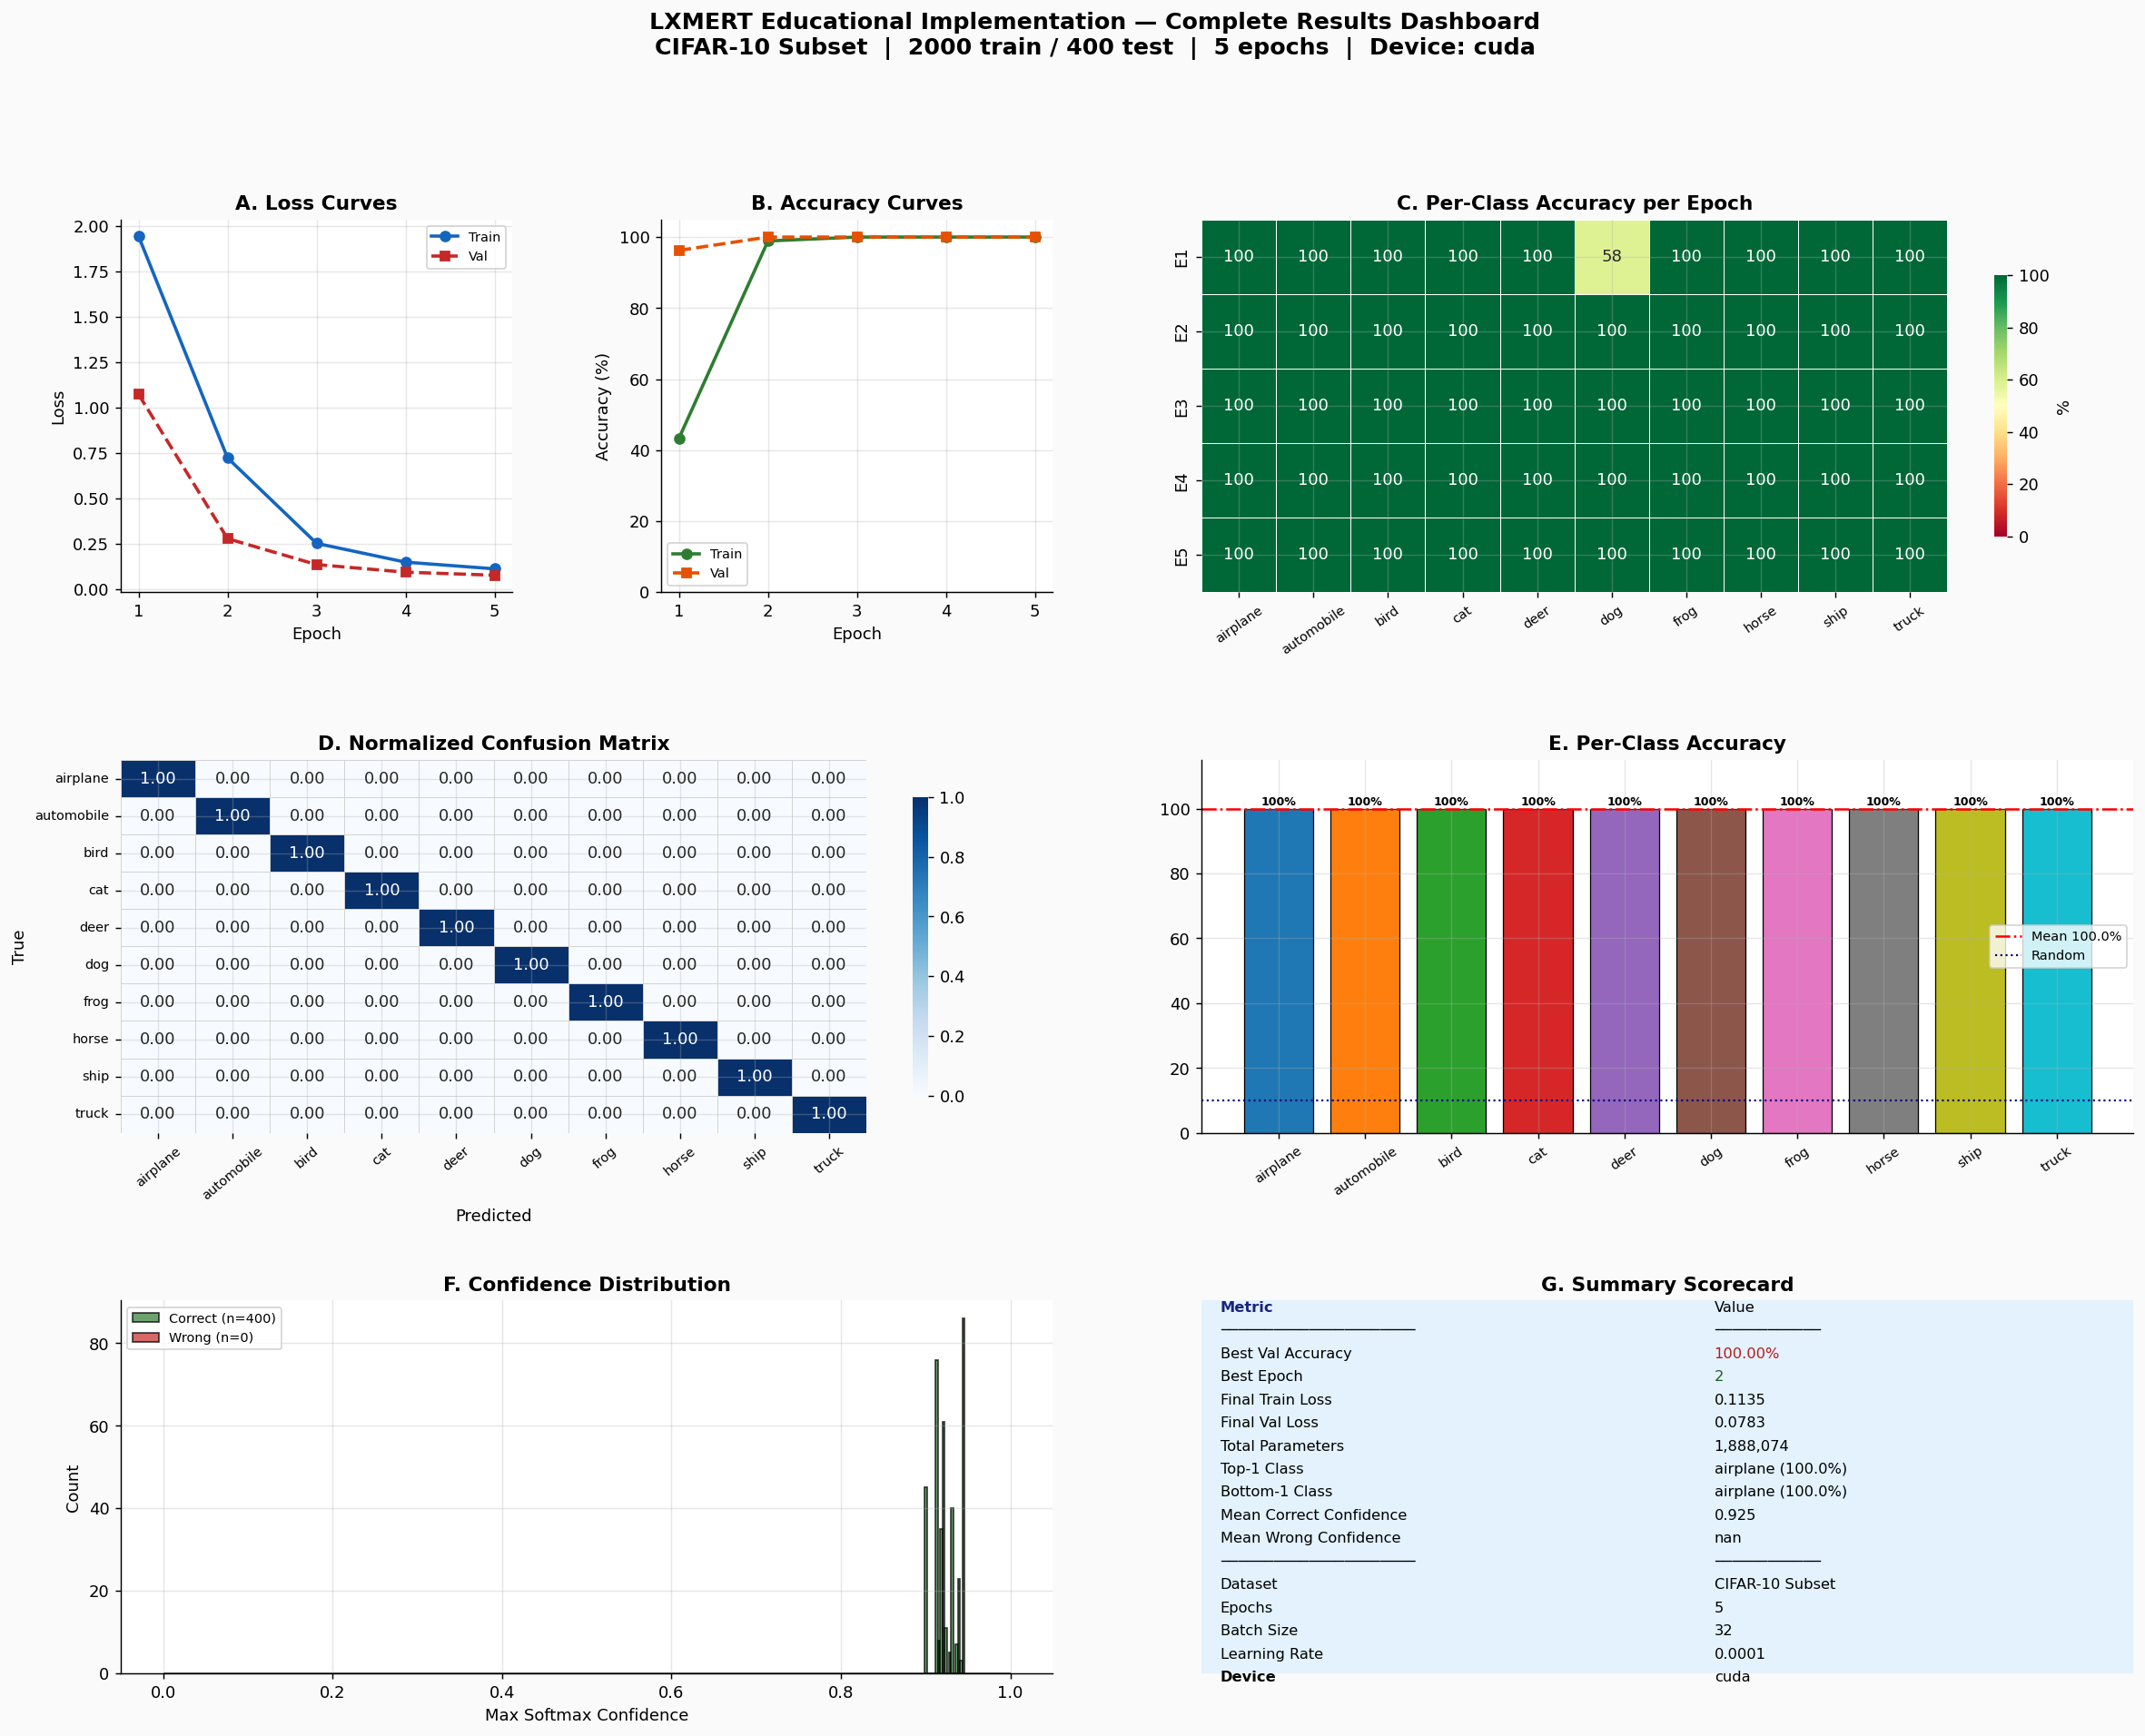

All 10 visualizations saved.


In [34]:
# ============================================================
# CELL 14: VISUALIZATION 10 — FINAL DASHBOARD
# ============================================================

fig = plt.figure(figsize=(22, 16))
fig.patch.set_facecolor("#FAFAFA")
fig.suptitle(
    "LXMERT Educational Implementation — Complete Results Dashboard\n"
    f"CIFAR-10 Subset  |  {SUBSET_TRAIN} train / {SUBSET_TEST} test  |  "
    f"{NUM_EPOCHS} epochs  |  Device: {DEVICE}",
    fontsize=14, fontweight="bold", y=0.99)

gs = gridspec.GridSpec(3, 4, figure=fig,
                       hspace=0.45, wspace=0.38)

# --- A: Loss ---
ax_loss = fig.add_subplot(gs[0, 0])
ax_loss.plot(epochs_x, history["tr_loss"], "o-", color="#1565C0",
             lw=2, label="Train")
ax_loss.plot(epochs_x, history["va_loss"], "s--", color="#C62828",
             lw=2, label="Val")
ax_loss.set_title("A. Loss Curves", fontweight="bold")
ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
ax_loss.set_xticks(epochs_x); ax_loss.legend(fontsize=8)

# --- B: Accuracy ---
ax_acc = fig.add_subplot(gs[0, 1])
ax_acc.plot(epochs_x, history["tr_acc"], "o-", color="#2E7D32",
            lw=2, label="Train")
ax_acc.plot(epochs_x, history["va_acc"], "s--", color="#E65100",
            lw=2, label="Val")
ax_acc.set_title("B. Accuracy Curves", fontweight="bold")
ax_acc.set_xlabel("Epoch"); ax_acc.set_ylabel("Accuracy (%)")
ax_acc.set_xticks(epochs_x); ax_acc.set_ylim(0,105)
ax_acc.legend(fontsize=8)

# --- C: Epoch heatmap ---
ax_eh = fig.add_subplot(gs[0, 2:])
sns.heatmap(epoch_class_acc,
            xticklabels=CIFAR10_CLASSES,
            yticklabels=[f"E{e}" for e in range(1,NUM_EPOCHS+1)],
            annot=True, fmt=".0f",
            cmap="RdYlGn", vmin=0, vmax=100,
            linewidths=0.5, linecolor="white",
            cbar_kws={"shrink":0.7,"label":"%"},
            ax=ax_eh)
ax_eh.set_title("C. Per-Class Accuracy per Epoch", fontweight="bold")
ax_eh.tick_params(axis="x", rotation=35, labelsize=8)

# --- D: Confusion matrix ---
ax_cm = fig.add_subplot(gs[1, :2])
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=CIFAR10_CLASSES,
            yticklabels=CIFAR10_CLASSES,
            cmap="Blues", vmin=0, vmax=1,
            linewidths=0.4, linecolor="lightgray",
            cbar_kws={"shrink":0.8},
            ax=ax_cm)
ax_cm.set_title("D. Normalized Confusion Matrix", fontweight="bold")
ax_cm.set_xlabel("Predicted"); ax_cm.set_ylabel("True")
ax_cm.tick_params(axis="x", rotation=40, labelsize=8)
ax_cm.tick_params(axis="y", rotation=0,  labelsize=8)

# --- E: Per-class bar ---
ax_pc = fig.add_subplot(gs[1, 2:])
brs   = ax_pc.bar(CIFAR10_CLASSES, per_class_acc,
                  color=CLASS_COLORS, edgecolor="black", lw=0.7)
ax_pc.axhline(np.mean(per_class_acc), color="red",
              ls="-.", lw=1.4,
              label=f"Mean {np.mean(per_class_acc):.1f}%")
ax_pc.axhline(10, color="navy", ls=":", lw=1.2, label="Random")
for b, a in zip(brs, per_class_acc):
    ax_pc.text(b.get_x()+b.get_width()/2, a+1.2,
               f"{a:.0f}%", ha="center", fontsize=7, fontweight="bold")
ax_pc.set_title("E. Per-Class Accuracy", fontweight="bold")
ax_pc.set_ylim(0, 115)
ax_pc.tick_params(axis="x", rotation=35, labelsize=8)
ax_pc.legend(fontsize=8)

# --- F: Confidence histogram ---
ax_conf = fig.add_subplot(gs[2, :2])
ax_conf.hist(all_confs_correct, bins=18, color="#2E7D32",
             alpha=0.7, edgecolor="black", lw=0.4,
             label=f"Correct (n={len(all_confs_correct)})")
ax_conf.hist(all_confs_wrong,   bins=18, color="#C62828",
             alpha=0.7, edgecolor="black", lw=0.4,
             label=f"Wrong (n={len(all_confs_wrong)})")
ax_conf.set_title("F. Confidence Distribution", fontweight="bold")
ax_conf.set_xlabel("Max Softmax Confidence")
ax_conf.set_ylabel("Count"); ax_conf.legend(fontsize=8)

# --- G: Summary scorecard ---
ax_sc = fig.add_subplot(gs[2, 2:])
ax_sc.axis("off")
best_ep  = history["va_acc"].index(max(history["va_acc"])) + 1
best_acc = max(history["va_acc"])
summary  = [
    ("Metric",                  "Value"),
    ("─"*22,                    "─"*12),
    ("Best Val Accuracy",        f"{best_acc:.2f}%"),
    ("Best Epoch",               f"{best_ep}"),
    ("Final Train Loss",         f"{history['tr_loss'][-1]:.4f}"),
    ("Final Val Loss",           f"{history['va_loss'][-1]:.4f}"),
    ("Total Parameters",         f"{n_params:,}"),
    ("Top-1 Class",
     f"{CIFAR10_CLASSES[np.argmax(per_class_acc)]} "
     f"({max(per_class_acc):.1f}%)"),
    ("Bottom-1 Class",
     f"{CIFAR10_CLASSES[np.argmin(per_class_acc)]} "
     f"({min(per_class_acc):.1f}%)"),
    ("Mean Correct Confidence",  f"{np.mean(all_confs_correct):.3f}"),
    ("Mean Wrong Confidence",    f"{np.mean(all_confs_wrong):.3f}"),
    ("─"*22,                    "─"*12),
    ("Dataset",                  "CIFAR-10 Subset"),
    ("Epochs",                   str(NUM_EPOCHS)),
    ("Batch Size",               str(BATCH_SIZE)),
    ("Learning Rate",            str(LR)),
    ("Device",                   str(DEVICE)),
]
for row, (k, v) in enumerate(summary):
    weight = "bold" if row in (0, 1, len(summary)-1) else "normal"
    color  = "#1A237E" if row == 0 else "black"
    ax_sc.text(0.02, 1 - row*0.062, k,
               transform=ax_sc.transAxes,
               fontsize=9, fontweight=weight, color=color, va="top")
    ax_sc.text(0.55, 1 - row*0.062, v,
               transform=ax_sc.transAxes,
               fontsize=9, color="#B71C1C" if row==2 else "#1B5E20"
               if row==3 else "black", va="top")
ax_sc.set_title("G. Summary Scorecard", fontweight="bold")
rect = mpatches.FancyBboxPatch(
    (0,0), 1, 1, boxstyle="round,pad=0.02",
    transform=ax_sc.transAxes, lw=1.5,
    edgecolor="#90CAF9", facecolor="#E3F2FD", zorder=0)
ax_sc.add_patch(rect)

plt.savefig("viz10_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("All 10 visualizations saved.")

# LXMERT: Related Work — Reference Table

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Vaswani et al. | 2017 | Attention Is All You Need | NeurIPS | Foundational Transformer architecture upon which all three LXMERT encoders (language, object-relationship, and cross-modality) are directly built. |
| Devlin et al. | 2019 | BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding | NAACL-HLT | Primary inspiration for LXMERT's masked language modeling pre-training task, WordPiece tokenization, and the use of a `[CLS]` token for aggregate sequence representation; LXMERT extends BERT to the cross-modality setting. |
| Anderson et al. | 2018 | Bottom-Up and Top-Down Attention for Image Captioning and Visual Question Answering | CVPR | Introduced the Bottom-Up Top-Down (BUTD) object RoI feature representation for images; LXMERT extends this approach by adding positional embeddings and an object-relationship encoder to model inter-object structure. |
| Peters et al. | 2018 | Deep Contextualized Word Representations (ELMo) | NAACL-HLT | Pioneered large-scale language model pre-training for contextual word representations; motivates LXMERT's adoption of the pre-train-then-fine-tune paradigm extended to the cross-modality domain. |
| Radford et al. | 2018 | Improving Language Understanding by Generative Pre-Training (GPT) | OpenAI Technical Report | Demonstrated the effectiveness of generative language model pre-training; part of the broader pre-training trend that LXMERT extends to vision-and-language tasks. |
| Lu et al. | 2016 | Hierarchical Question-Image Co-Attention for Visual Question Answering | NeurIPS | Introduced bidirectional attention between vision and language streams in VQA; directly motivates LXMERT's design of bidirectional cross-attention layers in the cross-modality encoder. |
| Seo et al. | 2017 | Bidirectional Attention Flow for Machine Comprehension (BiDAF) | ICLR | A concurrent work to Lu et al. (2016) that incorporated bidirectional attention with additional modeling layers in reading comprehension; cited as a parallel motivation for cross-modal bidirectional attention design. |
| Sun et al. | 2019 | VideoBERT: A Joint Model for Video and Language Representation Learning | arXiv | An early cross-modality pre-training model applying masked LM on concatenated visual tokens and language words; LXMERT differentiates itself by using a dedicated multi-encoder architecture and richer, task-diverse pre-training objectives. |
| Lample and Conneau | 2019 | Cross-Lingual Language Model Pretraining (XLM) | arXiv | Extended BERT-style pre-training to cross-lingual settings using monolingual and parallel data; cited as a related cross-modality pre-training effort, though focused on language-language rather than vision-language alignment. |
| Lu et al. | 2019 | ViLBERT: Pretraining Task-Agnostic Visiolinguistic Representations for Vision-and-Language Tasks | arXiv | A concurrent cross-modality pre-training model; LXMERT distinguishes itself through a more detailed multi-component architecture (object-relationship encoder, cross-modality layers) and additional pre-training tasks (RoI-feature regression, image QA), yielding superior results on VQA and NLVR2. |
| Li et al. | 2019 | VisualBERT: A Simple and Performant Baseline for Vision and Language | arXiv | Another concurrent vision-language pre-training model; cited for comparison, with LXMERT outperforming it by a margin of 1.5% on VQA 2.0 and 9% on NLVR2 accuracy. |
| Ren et al. | 2015 | Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks | NeurIPS | Provides the object detector used in LXMERT to extract fixed-size RoI features and bounding-box coordinates for all pre-training and fine-tuning images; frozen during LXMERT training. |
| Girshick et al. | 2014 | Rich Feature Hierarchies for Accurate Object Detection and Semantic Segmentation | CVPR | Foundational work in region-based object detection; part of the visual backbone lineage leading to Faster R-CNN used in LXMERT's image feature extraction pipeline. |
| He et al. | 2016 | Deep Residual Learning for Image Recognition | CVPR | Introduced ResNets as powerful visual backbone models; part of the vision pre-training literature that motivates LXMERT's adoption of pre-trained visual feature extractors. |
| Kim et al. | 2018 | Bilinear Attention Networks (BAN) | NeurIPS | Represents the prior state-of-the-art on VQA and GQA benchmarks at the time of LXMERT's submission; serves as the primary performance baseline against which LXMERT's improvements are measured. |
| Suhr et al. | 2019 | A Corpus for Reasoning about Natural Language Grounded in Photographs (NLVR2) | ACL | Introduced the NLVR2 visual reasoning benchmark used to evaluate LXMERT's generalizability; the 22% absolute accuracy improvement over the dataset's own SotA baseline (MaxEnt) is a central result of the paper. |
| Hudson and Manning | 2019 | GQA: A New Dataset for Compositional Question Answering over Real-World Images | CVPR | Introduced the GQA benchmark requiring multi-step spatial and compositional visual reasoning; used both as a pre-training data source and as a downstream evaluation dataset for LXMERT. |
| Antol et al. | 2015 | VQA: Visual Question Answering | ICCV | Introduced the original VQA benchmark; LXMERT uses its successor VQA v2.0 for both pre-training (question-answer pairs) and downstream evaluation. |
| Krishna et al. | 2017 | Visual Genome: Connecting Language and Vision Using Crowdsourced Dense Image Annotations | IJCV | Provides a major source of pre-training image-sentence and question-answer pairs (VG Captions, VG-QA) and supplies the training data used to pre-train the Faster R-CNN object detector adopted by LXMERT. |
| Lin et al. | 2014 | Microsoft COCO: Common Objects in Context | ECCV | Provides the other major source of pre-training data (COCO Captions); MS COCO images form a substantial portion of LXMERT's 180K pre-training image pool. |